## Data Collection

In [4]:
#importing libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,roc_auc_score,roc_curve
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,f1_score,precision_score,recall_score
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
df = pd.read_csv('players_21.csv')

In [6]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,Spain Primera Division,1.0,93,93,67500000,560000,"RW, ST, CF",Left,5,4,4,Medium/Low,Messi,Yes,138400000.0,"#Dribbler, #Distance Shooter, #FK Specialist, ...",CAM,10.0,NaN,2004-07-01,2021.0,RW,10.0,85.0,92.0,91.0,95.0,38.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,"Finesse Shot, Long Shot Taker (AI), Speed Drib...",85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,NaN,35,24,6,11,15,14,8,89+3,89+3,89+3,92+0,93+0,93+0,93+0,92+0,93+0,93+0,93+0,91+2,87+3,87+3,87+3,91+2,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,Italian Serie A,1.0,92,92,46000000,220000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,75900000.0,"#Aerial Threat, #Dribbler, #Distance Shooter, ...",LS,7.0,NaN,2018-07-10,2022.0,LS,7.0,89.0,93.0,81.0,89.0,35.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Flair, Long Shot Taker (AI), ...",84,95,90,82,86,88,81,76,77,92,87,91,87,95,71,94,95,84,78,93,63,29,95,82,84,95,NaN,32,24,7,11,15,14,11,91+1,91+1,91+1,89+0,91+0,91+0,91+0,89+0,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,Spain Primera Division,1.0,91,93,75000000,125000,GK,Right,3,3,1,Medium/Medium,PLAYER_BODY_TYPE_259,Yes,159400000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,90.0,52.0,90.0,"GK Long Throw, Comes For Crosses",13,11,15,43,13,12,13,14,40,30,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,NaN,12,18,87,92,78,90,90,33+3,33+3,33+3,32+0,35+0,35+0,35+0,32+0,38+3,38+3,38+3,35+3,38+3,38+3,38+3,35+3,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,German 1. Bundesliga,1.0,91,91,80000000,240000,ST,Right,4,4,4,High/Medium,PLAYER_BODY_TYPE_276,Yes,132000000.0,"#Distance Shooter, #Clinical Finisher",ST,9.0,NaN,2014-07-01,2023.0,NaN,NaN,78.0,91.0,78.0,85.0,43.0,82.0,NaN,NaN,NaN,NaN,NaN,NaN,"Solid Player, Finesse Shot, Outside Foot Shot,...",71,94,85,84,89,85,79,85,70,88,77,78,77,93,82,89,84,76,86,85,81,49,94,79,88,88,NaN,42,19,15,6,12,8,10,89+2,89+2,89+2,85+0,87+0,87+0,87+0,85+0,85+3,85+3,85+3,83+3,79+3,79+3,79+3,83+3,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos 

## Data Integration

In [7]:
df.shape

(18944, 106)

In [8]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,skill_moves,release_clause_eur,team_jersey_number,contract_valid_until,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18944.000000,18944.000000,18944.000000,18944.000000,18719.000000,18944.000000,18944.000000,1.894400e+04,18944.000000,18944.000000,18944.000000,18944.000000,1.794900e+04,18719.000000,18719.000000,1127.000000,16861.000000,16861.000000,16861.000000,16861.000000,16861.000000,16861.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,0.0,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000
mean,226242.402872,25.225823,181.190773,75.016892,1.357070,65.677787,71.086729,2.224813e+06,8675.852513,1.091850,2.936603,2.363017,4.296353e+06,20.589668,2021.983332,12.029281,67.668110,52.274954,57.139434,62.455430,51.316292,64.458988,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,49.612859,45.796083,51.874578,58.705448,42.669552,55.546400,47.187289,42.356155,52.653030,58.482791,64.285103,64.326489,63.333193,61.609428,63.918549,57.752798,64.590530,62.596020,64.742927,46.758763,55.488862,46.250000,50.255807,53.828231,48.050412,57.978674,NaN,47.581767,45.546505,16.446052,16.236486,16.103357,16.225982,16.551309
std,27171.091056,4.697354,6.825672,7.057140,0.739327,7.002278,6.109985,5.102486e+06,19654.774894,0.361841,0.667132,0.766469,1.005968e+07,17.057568,1.260426,6.674627,10.984862,13.991421,10.273655,10.048706,16.405179,9.746706,7.710474,7.328945,7.575184,8.126601,10.714523,8.565969,18.153057,19.592269,17.321709,14.572383,17.661569,18.787112,18.231204,17.239561,15.205281,16.598040,14.926452,14.689422,14.625189,9.112954,14.075215,13.330631,11.888479,15.878793,12.519775,19.305319,17.203045,20.738106,19.443738,13.724072,15.671721,12.118390,NaN,21.402461,20.953997,17.577332,16.845480,16.519399,17.017341,17.878121
min,41.000000,16.000000,155.000000,50.000000,1.000000,47.000000,47.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,9.000000e+03,1.000000,2020.000000,1.000000,25.000000,16.000000,25.000000,25.000000,15.000000,28.000000,45.000000,43.000000,35.000000,44.000000,12.000000,38.000000,6.000000,3.000000,5.000000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,5.000000,13.000000,12.000000,14.000000,24.000000,12.000000,18.000000,15.000000,12.000000,16.000000,4.000000,9.000000,3.000000,2.000000,9.000000,6.000000,12.000000,NaN,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,210030.500000,21.000000,176.000000,70.000000,1.000000,61.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,2.000000,5.250000e+05,9.000000,2021.000000,6.000000,62.000000,42.000000,50.000000,57.000000,36.000000,58.000000,60.000000,58.000000,57.000000,60.000000,28.000000,57.000000,38.000000,30.000000,44.000000,54.000000,30.000000,49.000000,35.000000,31.000000

In [9]:
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=106)

In [10]:
# Removing unneccessory columns
df=df.copy()
df.drop(["ls","st","rb","rcb","cb","lcb","lb","rwb","rdm","cdm","ldm","lwb","rm","rcm","cm","rs","lcm","lm","ram","cam","lam","rw","rf","cf","lf","lw"],axis=1,inplace=True)
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,Spain Primera Division,1.0,93,93,67500000,560000,"RW, ST, CF",Left,5,4,4,Medium/Low,Messi,Yes,138400000.0,"#Dribbler, #Distance Shooter, #FK Specialist, ...",CAM,10.0,NaN,2004-07-01,2021.0,RW,10.0,85.0,92.0,91.0,95.0,38.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,"Finesse Shot, Long Shot Taker (AI), Speed Drib...",85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,NaN,35,24,6,11,15,14,8
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,Italian Serie A,1.0,92,92,46000000,220000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,75900000.0,"#Aerial Threat, #Dribbler, #Distance Shooter, ...",LS,7.0,NaN,2018-07-10,2022.0,LS,7.0,89.0,93.0,81.0,89.0,35.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Flair, Long Shot Taker (AI), ...",84,95,90,82,86,88,81,76,77,92,87,91,87,95,71,94,95,84,78,93,63,29,95,82,84,95,NaN,32,24,7,11,15,14,11
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,Spain Primera Division,1.0,91,93,75000000,125000,GK,Right,3,3,1,Medium/Medium,PLAYER_BODY_TYPE_259,Yes,159400000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,90.0,52.0,90.0,"GK Long Throw, Comes For Crosses",13,11,15,43,13,12,13,14,40,30,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,NaN,12,18,87,92,78,90,90
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,German 1. Bundesliga,1.0,91,91,80000000,240000,ST,Right,4,4,4,High/Medium,PLAYER_BODY_TYPE_276,Yes,132000000.0,"#Distance Shooter, #Clinical Finisher",ST,9.0,NaN,2014-07-01,2023.0,NaN,NaN,78.0,91.0,78.0,85.0,43.0,82.0,NaN,NaN,NaN,NaN,NaN,NaN,"Solid Player, Finesse Shot, Outside Foot Shot,...",71,94,85,84,89,85,79,85,70,88,77,78,77,93,82,89,84,76,86,85,81,49,94,79,88,88,NaN,42,19,15,6,12,8,10
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,French Ligue 1,1.0,91,91,90000000,270000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,166500000.0,"#Speedster, #Dribbler, #Playmaker, #FK Special...",LW,10.0,NaN,2017-08-03,2022.0,NaN,NaN,91.0,85.0,86.0,94.0,36.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,"Injury Prone, Flair, Speed Dribbler (AI), Outs...",85,87,62,87,87,95,88,89,81,95,94,89,96,91,83,80,62,81,50,84,51,36,87,90,92,93,NaN,30,29,9,9,15,15,11


In [11]:
df.shape

(18944, 80)

In [12]:
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name', 'league_name',
       'league_rank', 'overall', 'potential', 'value_eur', 'wage_eur',
       'player_positions', 'preferred_foot', 'international_reputation',
       'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face',
       'release_clause_eur', 'player_tags', 'team_position',
       'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until',
       'nation_position', 'nation_jersey_number', 'pace', 'shooting',
       'passing', 'dribbling', 'defending', 'physic', 'gk_diving',
       'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed',
       'gk_positioning', 'player_traits', 'attacking_crossing',
       'attacking_finishing', 'attacking_heading_accuracy',
       'attacking_short_passing', 'attacking_volleys', 'skill_dribbling',
       'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
       'skill_ball_control', 

In [13]:
df.nunique()

sofifa_id                     18944
player_url                    18944
short_name                    17884
long_name                     18896
age                              29
dob                            6236
height_cm                        50
weight_kg                        56
nationality                     162
club_name                       681
league_name                      52
league_rank                       4
overall                          47
potential                        48
value_eur                       214
wage_eur                        142
player_positions                611
preferred_foot                    2
international_reputation          5
weak_foot                         5
skill_moves                       5
work_rate                         9
body_type                       118
real_face                         2
release_clause_eur             1225
player_tags                      75
team_position                    29
team_jersey_number          

In [14]:
df.duplicated().sum()

0

In [15]:
df.dtypes

sofifa_id                       int64
player_url                     object
short_name                     object
long_name                      object
age                             int64
dob                            object
height_cm                       int64
weight_kg                       int64
nationality                    object
club_name                      object
league_name                    object
league_rank                   float64
overall                         int64
potential                       int64
value_eur                       int64
wage_eur                        int64
player_positions               object
preferred_foot                 object
international_reputation        int64
weak_foot                       int64
skill_moves                     int64
work_rate                      object
body_type                      object
real_face                      object
release_clause_eur            float64
player_tags                    object
team_positio

In [16]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,skill_moves,release_clause_eur,team_jersey_number,contract_valid_until,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18944.000000,18944.000000,18944.000000,18944.000000,18719.000000,18944.000000,18944.000000,1.894400e+04,18944.000000,18944.000000,18944.000000,18944.000000,1.794900e+04,18719.000000,18719.000000,1127.000000,16861.000000,16861.000000,16861.000000,16861.000000,16861.000000,16861.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,0.0,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000
mean,226242.402872,25.225823,181.190773,75.016892,1.357070,65.677787,71.086729,2.224813e+06,8675.852513,1.091850,2.936603,2.363017,4.296353e+06,20.589668,2021.983332,12.029281,67.668110,52.274954,57.139434,62.455430,51.316292,64.458988,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,49.612859,45.796083,51.874578,58.705448,42.669552,55.546400,47.187289,42.356155,52.653030,58.482791,64.285103,64.326489,63.333193,61.609428,63.918549,57.752798,64.590530,62.596020,64.742927,46.758763,55.488862,46.250000,50.255807,53.828231,48.050412,57.978674,NaN,47.581767,45.546505,16.446052,16.236486,16.103357,16.225982,16.551309
std,27171.091056,4.697354,6.825672,7.057140,0.739327,7.002278,6.109985,5.102486e+06,19654.774894,0.361841,0.667132,0.766469,1.005968e+07,17.057568,1.260426,6.674627,10.984862,13.991421,10.273655,10.048706,16.405179,9.746706,7.710474,7.328945,7.575184,8.126601,10.714523,8.565969,18.153057,19.592269,17.321709,14.572383,17.661569,18.787112,18.231204,17.239561,15.205281,16.598040,14.926452,14.689422,14.625189,9.112954,14.075215,13.330631,11.888479,15.878793,12.519775,19.305319,17.203045,20.738106,19.443738,13.724072,15.671721,12.118390,NaN,21.402461,20.953997,17.577332,16.845480,16.519399,17.017341,17.878121
min,41.000000,16.000000,155.000000,50.000000,1.000000,47.000000,47.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,9.000000e+03,1.000000,2020.000000,1.000000,25.000000,16.000000,25.000000,25.000000,15.000000,28.000000,45.000000,43.000000,35.000000,44.000000,12.000000,38.000000,6.000000,3.000000,5.000000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,5.000000,13.000000,12.000000,14.000000,24.000000,12.000000,18.000000,15.000000,12.000000,16.000000,4.000000,9.000000,3.000000,2.000000,9.000000,6.000000,12.000000,NaN,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,210030.500000,21.000000,176.000000,70.000000,1.000000,61.000000,67.000000,3.000000e+05,1000.000000,1.000000,3.000000,2.000000,5.250000e+05,9.000000,2021.000000,6.000000,62.000000,42.000000,50.000000,57.000000,36.000000,58.000000,60.000000,58.000000,57.000000,60.000000,28.000000,57.000000,38.000000,30.000000,44.000000,54.000000,30.000000,49.000000,35.000000,31.000000

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18944 entries, 0 to 18943
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sofifa_id                   18944 non-null  int64  
 1   player_url                  18944 non-null  object 
 2   short_name                  18944 non-null  object 
 3   long_name                   18944 non-null  object 
 4   age                         18944 non-null  int64  
 5   dob                         18944 non-null  object 
 6   height_cm                   18944 non-null  int64  
 7   weight_kg                   18944 non-null  int64  
 8   nationality                 18944 non-null  object 
 9   club_name                   18719 non-null  object 
 10  league_name                 18719 non-null  object 
 11  league_rank                 18719 non-null  float64
 12  overall                     18944 non-null  int64  
 13  potential                   189

In [18]:
import researchpy as rp

num_cols = df.select_dtypes(include = np.number).columns
rp.summary_cont(df[num_cols])

,Variable,N,Mean,SD,SE,95% Conf.,Interval
0,sofifa_id,18944.0,2.262424e+05,2.717109e+04,197.4109,2.258555e+05,2.266293e+05
1,age,18944.0,2.522580e+01,4.697400e+00,0.0341,2.515890e+01,2.529270e+01
2,height_cm,18944.0,1.811908e+02,6.825700e+00,0.0496,1.810936e+02,1.812880e+02
3,weight_kg,18944.0,7.501690e+01,7.057100e+00,0.0513,7.491640e+01,7.511740e+01
4,league_rank,18719.0,1.357100e+00,7.393000e-01,0.0054,1.346500e+00,1.367700e+00
5,overall,18944.0,6.567780e+01,7.002300e+00,0.0509,6.557810e+01,6.577750e+01
6,potential,18944.0,7.108670e+01,6.110000e+00,0.0444,7.099970e+01,7.117370e+01
7,value_eur,18944.0,2.224813e+06,5.102486e+06,37071.9968,2.152149e+06,2.297478e+06
8,wage_eur,18944.0,8.675853e+03,1.965477e+04,142.8013,8.395949e+03,8.955756e+03
9,international_reputation,18944.0,1.091800e+00,3.618000e-01,0.0026,1.086700e+00,1.097000e+00


In [19]:
# convert object features to datetime

from datetime import datetime as dt

df["dob"]=pd.to_datetime(df["dob"])
df["joined"]=pd.to_datetime(df["joined"])

df["born_year"]=df["dob"].dt.year

# converting value features:

df["value_eur"]=df["value_eur"]/1000000
df["wage_eur"]=(df["wage_eur"]*48)/1000000
df["release_clause_eur"]=df["release_clause_eur"]/1000000

#RENAME THE  COLUMNS:
df.rename(columns={"value_eur":"value_eur_m","wage_eur":"wage_eur_m","release_clause_eur":"release_clause_eur_m"},inplace=True)

# CREATE NEW FEATURES:

# league value
df["league_value_B"]=df.groupby("league_name")["value_eur_m"].transform("sum")/1000

# position_area(attack,defense,midfield,goalkeeper):

df["team_position"]=df["team_position"].apply(lambda x: "attack" if x in ["LS","ST","RS","LW","LF","CF","RF","RW"] 
                                              else ("defense" if x in ["LWB","LB","LCB","CB","RCB","RB"] else 
                                                    ("midfield" if x in ["LDM","CDM","RDM","LM","LCM","CM","RCM","RM","LAM","CAM","RAM"] 
                                                     else("goalkeeper" if x in ["GK"] else "none"))))


# loyalty feature: how many years the player has been in the club
df["loyalty"]=2020-df["joined"].dt.year

# body type availablity

df["body_type"]=df["body_type"].apply(lambda x: "not famous" if x.startswith("PLAYER_BODY_TYPE_") else "famous")

                                                                                 
# number of player traits:

df["player_traits"]=df["player_traits"].apply(lambda x: len(x.split(",")) if type(x)==str else 0)

# team quelity:

vf=df.groupby("club_name")[["value_eur_m"]].sum().sort_values(by="value_eur_m",ascending=False).head(500)

df["team_quality"]=df["club_name"].apply(lambda x: "hight_quality" if x in vf.index else "low_quality")


df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,potential,value_eur_m,wage_eur_m,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur_m,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,born_year,league_value_B,loyalty,team_quality
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,Spain Primera Division,1.0,93,93,67.5,26.88,"RW, ST, CF",Left,5,4,4,Medium/Low,famous,Yes,138.4,"#Dribbler, #Distance Shooter, #FK Specialist, ...",midfield,10.0,NaN,2004-07-01,2021.0,RW,10.0,85.0,92.0,91.0,95.0,38.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,8,85,95,70,91,88,96,93,94,91,96,91,80,91,94,95,86,68,72,69,94,44,40,93,95,75,96,NaN,35,24,6,11,15,14,8,1987,5.266865,16.0,hight_quality
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,Italian Serie A,1.0,92,92,46.0,10.56,"ST, LW",Right,5,4,5,High/Low,famous,Yes,75.9,"#Aerial Threat, #Dribbler, #Distance Shooter, ...",attack,7.0,NaN,2018-07-10,2022.0,LS,7.0,89.0,93.0,81.0,89.0,35.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,5,84,95,90,82,86,88,81,76,77,92,87,91,87,95,71,94,95,84,78,93,63,29,95,82,84,95,NaN,32,24,7,11,15,14,11,1985,3.984970,2.0,hight_quality
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,Spain Primera Division,1.0,91,93,75.0,6.00,GK,Right,3,3,1,Medium/Medium,not famous,Yes,159.4,NaN,goalkeeper,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,90.0,52.0,90.0,2,13,11,15,43,13,12,13,14,40,30,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,NaN,12,18,87,92,78,90,90,1993,5.266865,6.0,hight_quality
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,German 1. Bundesliga,1.0,91,91,80.0,11.52,ST,Right,4,4,4,High/Medium,not famous,Yes,132.0,"#Distance Shooter, #Clinical Finisher",attack,9.0,NaN,2014-07-01,2023.0,NaN,NaN,78.0,91.0,78.0,85.0,43.0,82.0,NaN,NaN,NaN,NaN,NaN,NaN,4,71,94,85,84,89,85,79,85,70,88,77,78,77,93,82,89,84,76,86,85,81,49,94,79,88,88,NaN,42,19,15,6,12,8,10,1988,3.858735,6.0,hight_quality
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,French Ligue 1,1.0,91,91,90.0,12.96,"LW, CAM",Right,5,5,5,High/Medium,famous,Yes,166.5,"#Speedster, #Dribbler, #Playmaker, #FK Special...",attack,10.0,NaN,2017-08-03,2022.0,NaN,NaN,91.0,85.0,86.0,94.0,36.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,5,85,87,62,87,87,95,88,89,81,95,94,89,96,91,83,80,62,81,50,84,51,36,87,90,92,93,NaN,30,29,9,9,15,15,11,1992,2.948835,3.0,hight_quality


In [20]:
# Checking Null Value
df.isnull().sum()

sofifa_id                         0
player_url                        0
short_name                        0
long_name                         0
age                               0
dob                               0
height_cm                         0
weight_kg                         0
nationality                       0
club_name                       225
league_name                     225
league_rank                     225
overall                           0
potential                         0
value_eur_m                       0
wage_eur_m                        0
player_positions                  0
preferred_foot                    0
international_reputation          0
weak_foot                         0
skill_moves                       0
work_rate                         0
body_type                         0
real_face                         0
release_clause_eur_m            995
player_tags                   17536
team_position                     0
team_jersey_number          

<Axes: >

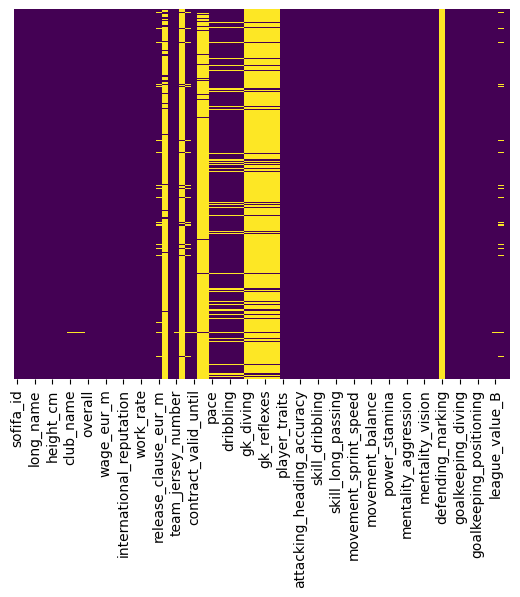

In [21]:
# Checking null values using heatmap
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [22]:
# show the missing values in dataset with ratio
def missing_values_tabl(df):
    
    na_columns = [col for col in df.columns if df[col].isnull().sum() > 0]
    n_miss = df[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (df[na_columns].isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio,2)], axis=1, keys=['n_miss', 'ratio'])
    missing_df = pd.DataFrame(missing_df)
    return missing_df

missing_values_tabl(df)

,n_miss,ratio
defending_marking,18944,100.00
loaned_from,18186,96.00
nation_position,17817,94.05
nation_jersey_number,17817,94.05
player_tags,17536,92.57
gk_reflexes,16861,89.00
gk_kicking,16861,89.00
gk_handling,16861,89.00
gk_diving,16861,89.00
gk_speed,16861,89.00


In [23]:
# handling the missing values by using KNN imputer

num=df.select_dtypes(include=['float64','int64'])


for i in df.columns:
    if df[i].isnull().sum()>len(df)*0.90:
        df.drop(i,axis=1,inplace=True)
     
df.isnull().sum()

sofifa_id                         0
player_url                        0
short_name                        0
long_name                         0
age                               0
dob                               0
height_cm                         0
weight_kg                         0
nationality                       0
club_name                       225
league_name                     225
league_rank                     225
overall                           0
potential                         0
value_eur_m                       0
wage_eur_m                        0
player_positions                  0
preferred_foot                    0
international_reputation          0
weak_foot                         0
skill_moves                       0
work_rate                         0
body_type                         0
real_face                         0
release_clause_eur_m            995
team_position                     0
team_jersey_number              225
joined                      

In [24]:
from sklearn.impute import KNNImputer
knn=KNNImputer(n_neighbors=15)
num=df.select_dtypes(include=['float64','int64'])    
for i in num.columns:
   df[i]=knn.fit_transform(df[[i]])
      
df.isnull().sum()

sofifa_id                       0
player_url                      0
short_name                      0
long_name                       0
age                             0
dob                             0
height_cm                       0
weight_kg                       0
nationality                     0
club_name                     225
league_name                   225
league_rank                     0
overall                         0
potential                       0
value_eur_m                     0
wage_eur_m                      0
player_positions                0
preferred_foot                  0
international_reputation        0
weak_foot                       0
skill_moves                     0
work_rate                       0
body_type                       0
real_face                       0
release_clause_eur_m            0
team_position                   0
team_jersey_number              0
joined                        983
contract_valid_until            0
pace          

## Exploratory Data Analysis (EDA)

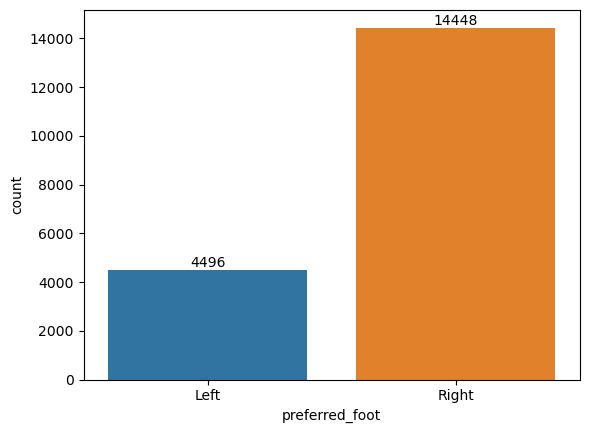

In [25]:
ax = sns.countplot(data=df,x='preferred_foot')
for bars in ax.containers:
    ax.bar_label(bars)

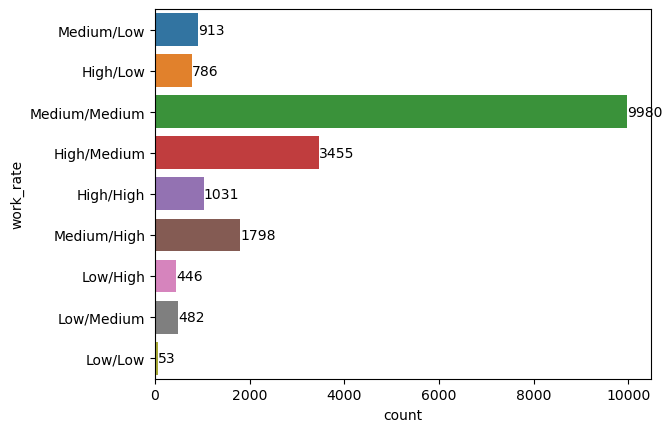

In [26]:
ax = sns.countplot(data=df,y='work_rate')
for bars in ax.containers:
    ax.bar_label(bars)

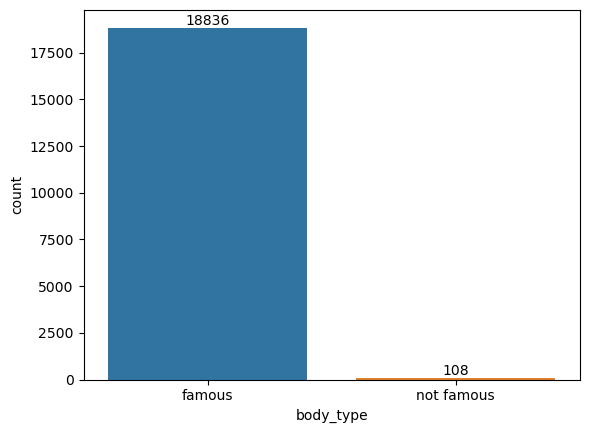

In [27]:
ax = sns.countplot(data=df,x='body_type')
for bars in ax.containers:
    ax.bar_label(bars)

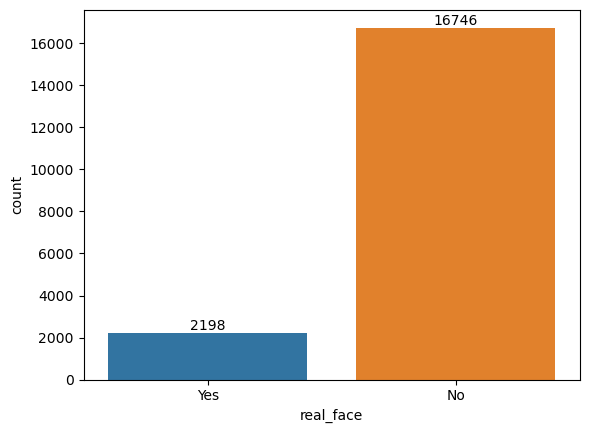

In [28]:
ax = sns.countplot(data=df,x='real_face')
for bars in ax.containers:
    ax.bar_label(bars)

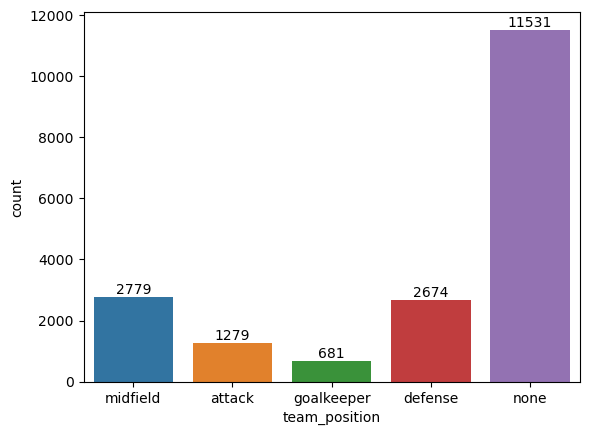

In [29]:
ax = sns.countplot(data=df,x='team_position')
for bars in ax.containers:
    ax.bar_label(bars)

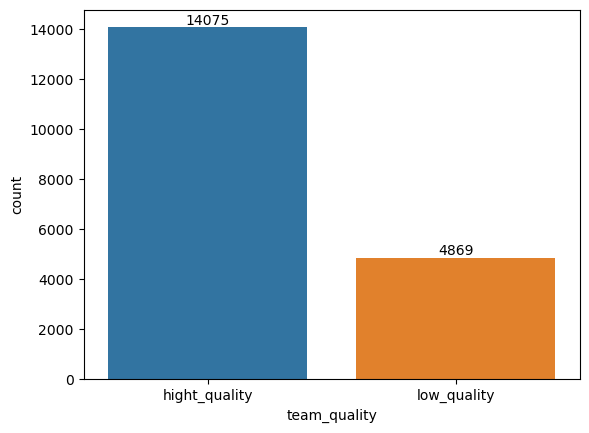

In [30]:
ax = sns.countplot(data=df,x='team_quality')
for bars in ax.containers:
    ax.bar_label(bars)

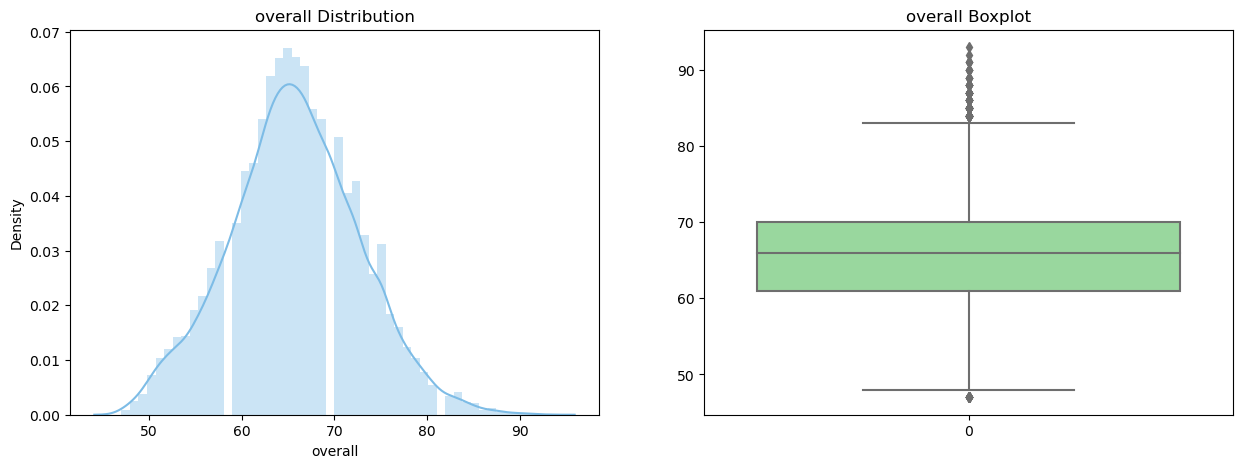

count    18944.000000
mean        65.677787
std          7.002278
min         47.000000
25%         61.000000
50%         66.000000
75%         70.000000
max         93.000000
Name: overall, dtype: float64
Skewness: 0.089313
Kurtosis: -0.002538
****************************


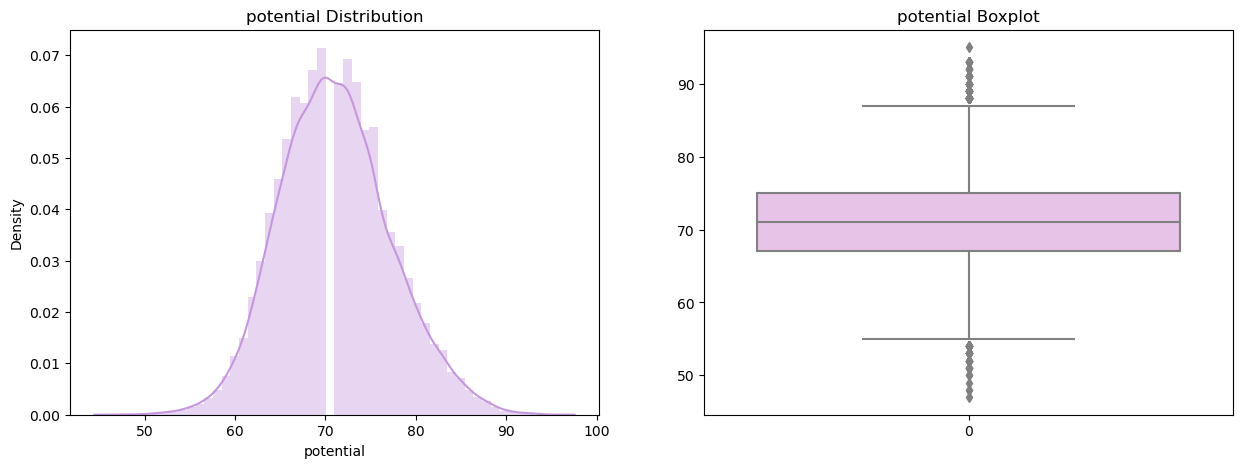

count    18944.000000
mean        71.086729
std          6.109985
min         47.000000
25%         67.000000
50%         71.000000
75%         75.000000
max         95.000000
Name: potential, dtype: float64
Skewness: 0.217394
Kurtosis: 0.092657
****************************


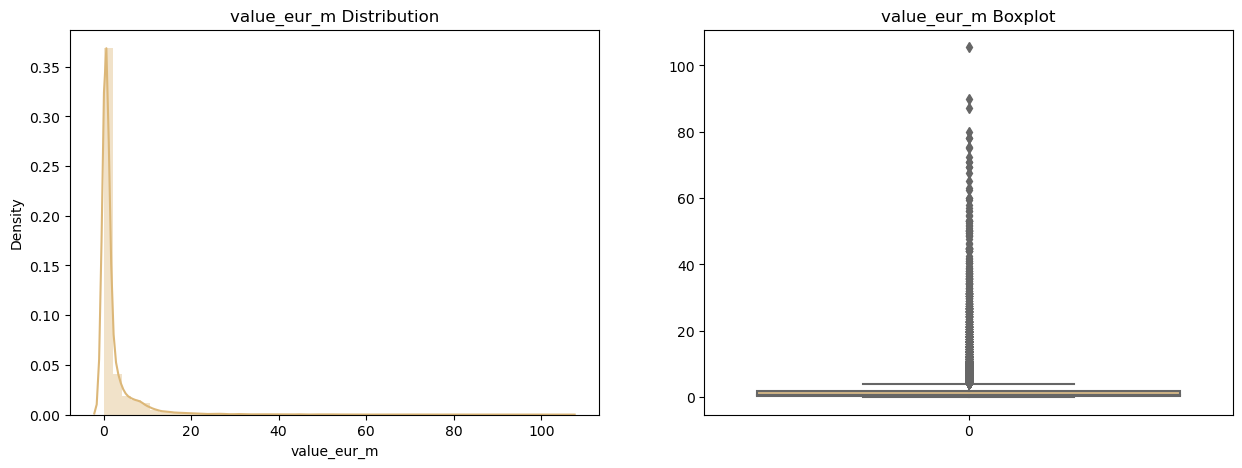

count    18944.000000
mean         2.224813
std          5.102486
min          0.000000
25%          0.300000
50%          0.650000
75%          1.800000
max        105.500000
Name: value_eur_m, dtype: float64
Skewness: 6.727281
Kurtosis: 68.855929
****************************


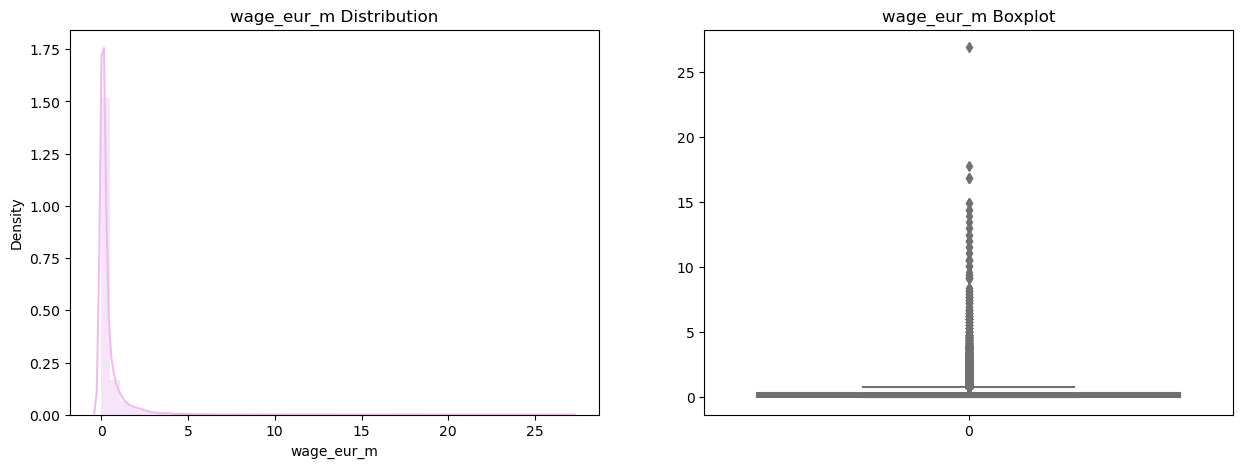

count    18944.000000
mean         0.416441
std          0.943429
min          0.000000
25%          0.048000
50%          0.144000
75%          0.336000
max         26.880000
Name: wage_eur_m, dtype: float64
Skewness: 7.484533
Kurtosis: 96.591958
****************************


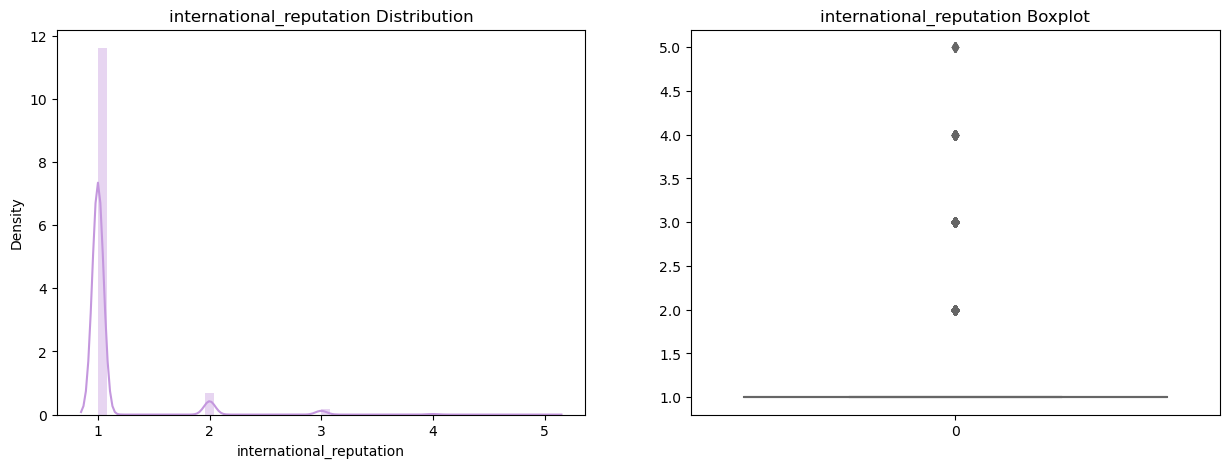

count    18944.000000
mean         1.091850
std          0.361841
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: international_reputation, dtype: float64
Skewness: 4.618014
Kurtosis: 24.559540
****************************


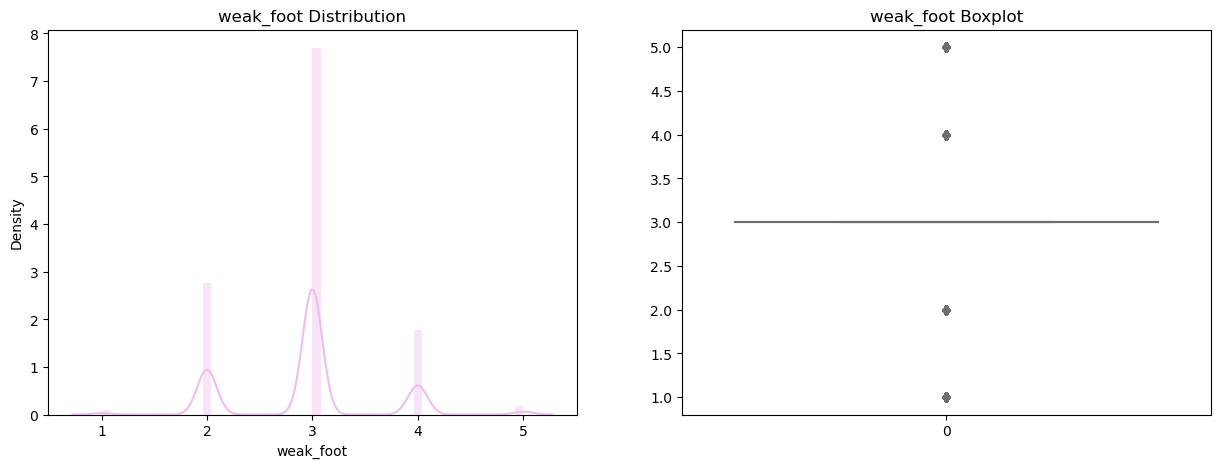

count    18944.000000
mean         2.936603
std          0.667132
min          1.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: weak_foot, dtype: float64
Skewness: 0.219654
Kurtosis: 0.601850
****************************


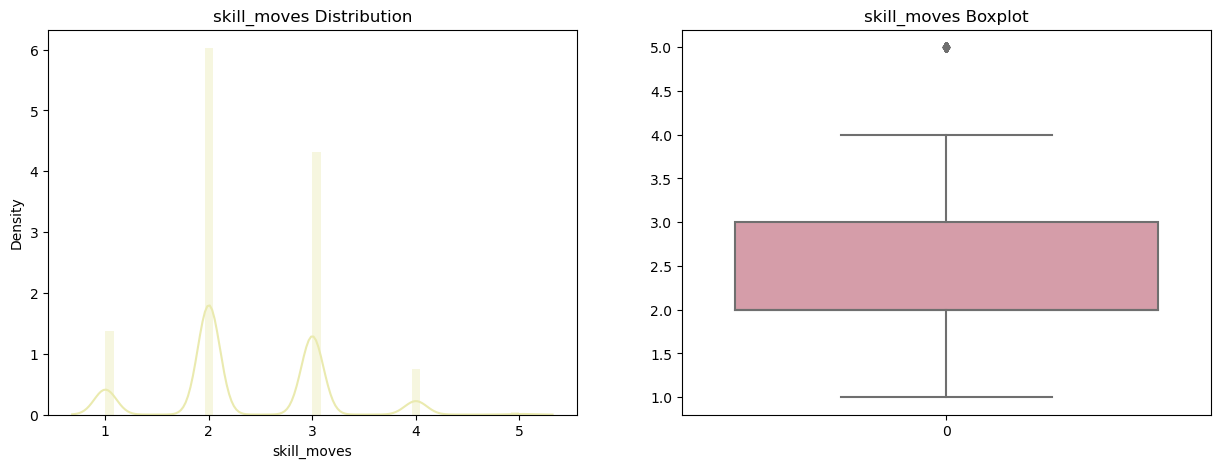

count    18944.000000
mean         2.363017
std          0.766469
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: skill_moves, dtype: float64
Skewness: 0.225260
Kurtosis: -0.067779
****************************


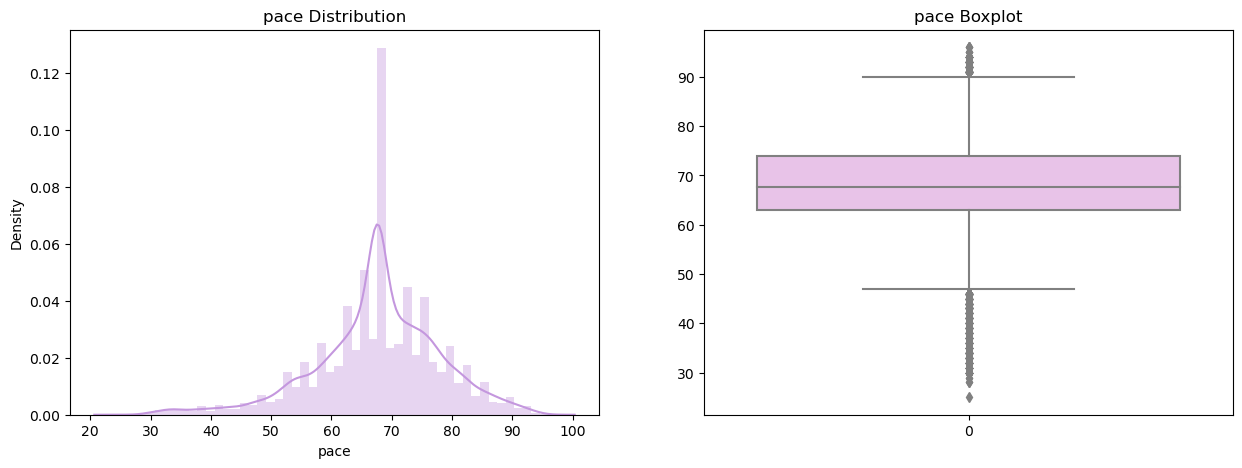

count    18944.000000
mean        67.668110
std         10.363322
min         25.000000
25%         63.000000
50%         67.668110
75%         74.000000
max         96.000000
Name: pace, dtype: float64
Skewness: -0.539655
Kurtosis: 1.101084
****************************


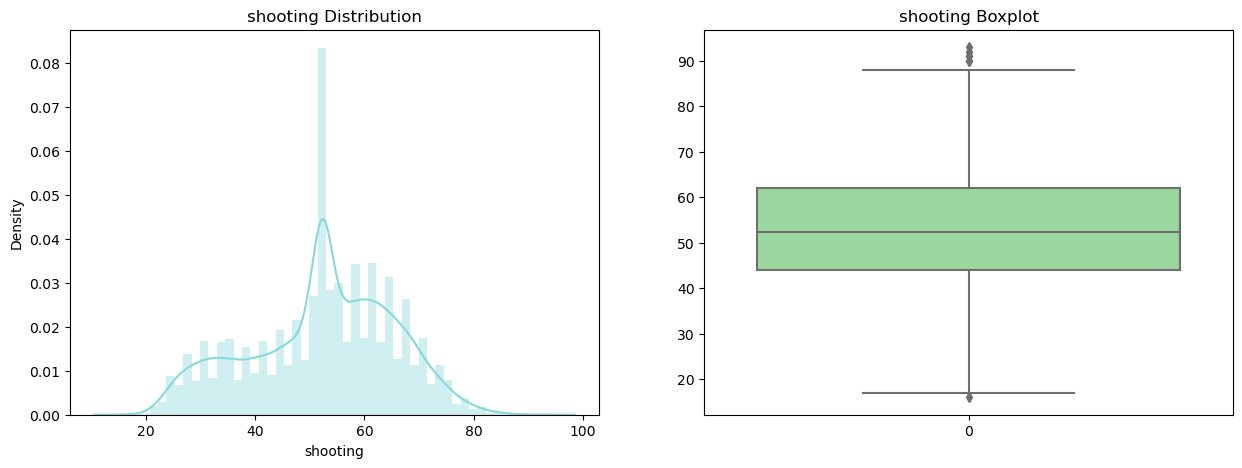

count    18944.000000
mean        52.274954
std         13.199766
min         16.000000
25%         44.000000
50%         52.274954
75%         62.000000
max         93.000000
Name: shooting, dtype: float64
Skewness: -0.287125
Kurtosis: -0.497940
****************************


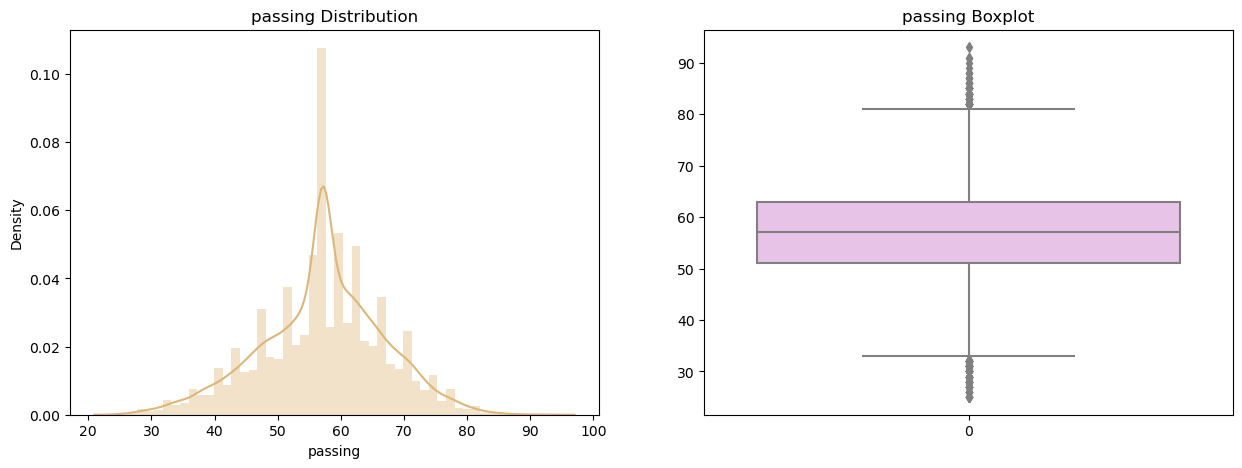

count    18944.000000
mean        57.139434
std          9.692357
min         25.000000
25%         51.000000
50%         57.139434
75%         63.000000
max         93.000000
Name: passing, dtype: float64
Skewness: -0.199215
Kurtosis: 0.218255
****************************


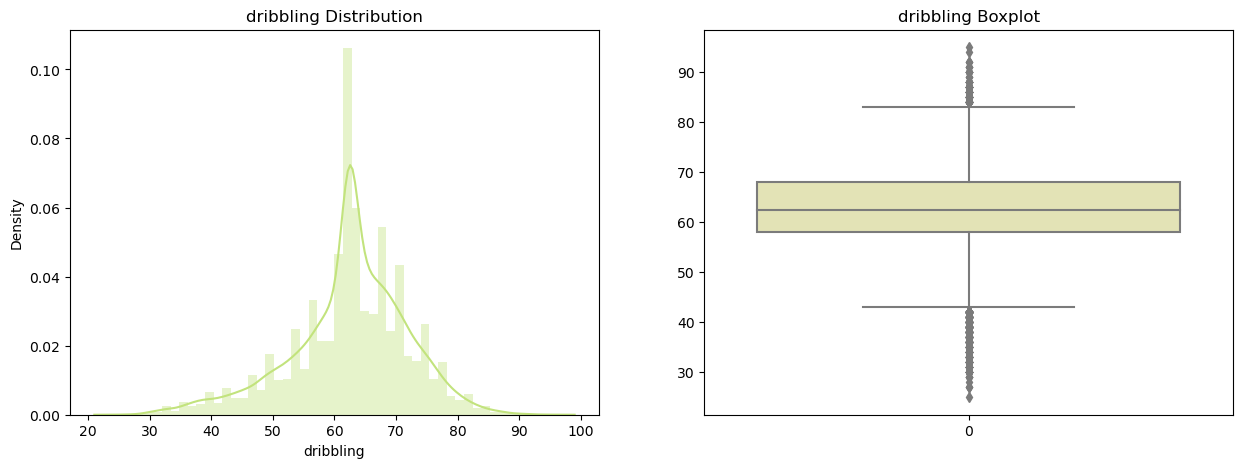

count    18944.000000
mean        62.455430
std          9.480136
min         25.000000
25%         58.000000
50%         62.455430
75%         68.000000
max         95.000000
Name: dribbling, dtype: float64
Skewness: -0.552649
Kurtosis: 0.782478
****************************


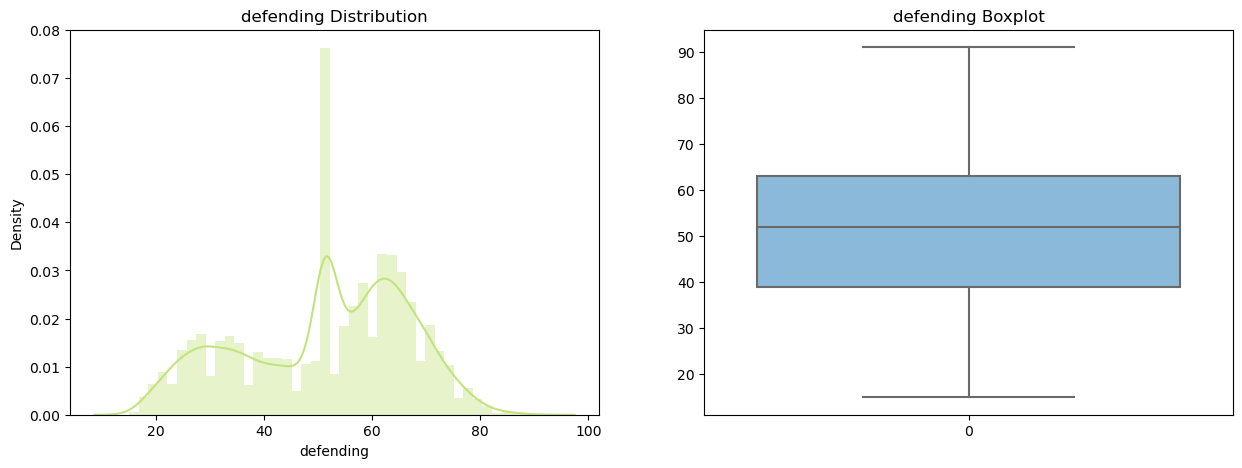

count    18944.000000
mean        51.316292
std         15.476950
min         15.000000
25%         39.000000
50%         52.000000
75%         63.000000
max         91.000000
Name: defending, dtype: float64
Skewness: -0.374699
Kurtosis: -0.801525
****************************


In [31]:
# distribution of the features

colors = ['#7DBCE6','#EEBDEE','#EAEAAF','#8FE195','#E28181',
          '#87D8DB','#C2E37D','#DF93A4','#DCB778','#C497DE']

features=['overall','potential','value_eur_m','wage_eur_m','international_reputation','weak_foot','skill_moves',
            'pace','shooting','passing','dribbling','defending']

def num_summary(dataframe, col_name):
    fig, ax = plt.subplots(1,2,figsize=(15,5))
    sns.distplot(dataframe[col_name], ax=ax[0], color=np.random.choice(colors))
    ax[0].set_title(col_name + ' Distribution')
    sns.boxplot(dataframe[col_name], ax=ax[1], color=np.random.choice(colors))
    ax[1].set_title(col_name + ' Boxplot')
    plt.show()
    print(dataframe[col_name].describe().T)
    print("Skewness: %f" % dataframe[col_name].skew())
    print("Kurtosis: %f" % dataframe[col_name].kurt())
    print("****************************")


for i in df[features].columns:
    num_summary(df,i)

In [29]:
# pairplot of the selected features

features=['overall','potential','value_eur_m','wage_eur_m','international_reputation','weak_foot','skill_moves',
            'pace','shooting','passing','dribbling','defending',"preferred_foot"]


plt.figure(figsize=(20,20))
sns.set_style("darkgrid")
sns.pairplot(df[features],kind="reg",diag_kind="kde",palette="husl",hue="preferred_foot");
plt.title("Distribution of all Variables")

In [33]:
top_10_fast_players = df.sort_values(by='pace',ascending=False).head(10)
top_10_fast_players

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,potential,value_eur_m,wage_eur_m,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur_m,team_position,team_jersey_number,joined,contract_valid_until,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,born_year,league_value_B,loyalty,team_quality
518,213956.0,https://sofifa.com/player/213956/adama-traore-...,Adama Traoré,Adama Traoré Diarra,24.0,1996-01-25,178.0,72.0,Spain,Wolverhampton Wanderers,English Premier League,1.0,79.0,85.0,17.5,3.840,"RW, RWB",Right,1.0,2.0,4.0,High/Low,not famous,Yes,36.800000,none,37.0,2018-08-08,2023.0,96.0,66.0,68.0,87.0,38.0,81.0,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,2.0,79.0,66.0,40.0,72.0,52.0,92.0,67.0,42.0,54.0,83.0,97.0,96.0,85.0,66.0,88.0,78.0,79.0,77.0,87.0,65.0,70.0,41.0,64.0,69.0,47.0,73.0,38.0,35.0,13.0,9.0,11.0,12.0,7.0,1996.0,6.444575,2.000000,hight_quality
6,231747.0,https://sofifa.com/player/231747/kylian-mbappe...,K. Mbappé,Kylian Mbappé Lottin,21.0,1998-12-20,178.0,73.0,France,Paris Saint-Germain,French Ligue 1,1.0,90.0,95.0,105.5,7.680,"ST, LW, RW",Right,3.0,4.0,5.0,High/Low,not famous,Yes,203.100000,attack,7.0,2018-07-01,2022.0,96.0,86.0,78.0,91.0,39.0,76.0,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,5.0,78.0,91.0,73.0,83.0,83.0,92.0,79.0,63.0,70.0,90.0,96.0,96.0,92.0,92.0,82.0,86.0,77.0,86.0,76.0,79.0,62.0,38.0,91.0,80.0,70.0,84.0,34.0,32.0,13.0,5.0,7.0,11.0,6.0,1998.0,2.948835,2.000000,hight_quality
273,234396.0,https://sofifa.com/player/234396/alphonso-davi...,A. Davies,Alphonso Davies,19.0,2000-11-02,181.0,72.0,Canada,FC Bayern München,German 1. Bundesliga,1.0,81.0,89.0,22.5,1.920,"LB, LM, RM",Left,1.0,4.0,4.0,High/Medium,not famous,Yes,41.600000,defense,19.0,2019-01-01,2025.0,96.0,67.0,69.0,83.0,76.0,76.0,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,2.0,73.0,67.0,64.0,77.0,59.0,85.0,67.0,44.0,58.0,79.0,96.0,96.0,85.0,79.0,82.0,71.0,77.0,79.0,74.0,63.0,77.0,76.0,75.0,68.0,60.0,74.0,77.0,79.0,11.0,11.0,6.0,5.0,14.0,2000.0,3.858735,1.000000,hight_quality
366,238794.0,https://sofifa.com/player/238794/vinicius-jose...,Vinícius Jr.,Vinícius José Paixão de Oliveira Júnior,19.0,2000-07-12,176.0,73.0,Brazil,Real Madrid,Spain Primera Division,1.0,80.0,93.0,27.5,4.560,LW,Right,2.0,4.0,5.0,High/Medium,famous,Yes,73.600000,none,20.0,2018-07-12,2025.0,95.0,69.0,71.0,87.0,29.0,66.0,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,4.0,71.0,68.0,50.0,72.0,70.0,88.0,77.0,62.0,67.0,85.0,95.0,95.0,94.0,75.0,82.0,73.0,75.0,79.0,62.0,68.0,58.0,26.0,75.0,73.0,65.0,74.0,25.0,18.0,5.0,7.0,7.0,7.0,10.0,2000.0,5.266865,2.000000,hight_quality
5564,236943.0,https://sofifa.com/player/236943/anibal-chala/...,A. Chalá,Aníbal Hernán Chalá Ayoví,24.0,1996-05-09,179.0,70.0,Ecuador,Dijon FCO,French Ligue 1,1.0,69.0,76.0,1.3,0.288,"LB, LM",Left,1.0,3.0,2.0,High/Medium,famous,No,4.296353,none,13.0,NaT,2021.0,95.0,46.0,59.0,59.0,64.0,66.0,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,1.0,59.0,38.0,56.0,66.0,36.0,58.0,49.0,31.0,59.0,55.0,93.0,96.0,70.0,58.0,64.0,61.0,66.0,75.0,60.0,42.0,70.0,63.0,70.0,58.0,54.0,60.0,65.0,62.0,6

Text(0.5, 1.0, 'Top 10 Fastest Players')

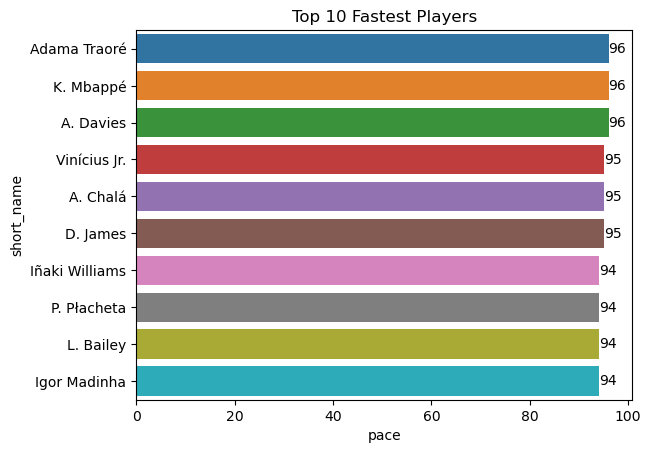

In [34]:
ax=sns.barplot(y=top_10_fast_players["short_name"],x=top_10_fast_players["pace"])
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Top 10 Fastest Players")

In [35]:
top_10_longest_players=df.sort_values(by='height_cm', ascending=False).head(10)
top_10_longest_players

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,league_name,league_rank,overall,potential,value_eur_m,wage_eur_m,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur_m,team_position,team_jersey_number,joined,contract_valid_until,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,born_year,league_value_B,loyalty,team_quality
10171,199321.0,https://sofifa.com/player/199321/tomas-holy/21...,T. Holý,Tomáš Holý,28.0,1991-12-10,206.0,102.0,Czech Republic,Ipswich Town,English League One,3.0,65.0,67.0,0.475,0.1440,GK,Right,1.0,3.0,1.0,Medium/Medium,famous,No,0.867,goalkeeper,1.0,2019-07-01,2022.0,67.66811,52.274954,57.139434,62.45543,51.316292,64.458988,68.000000,60.000000,56.000000,69.000000,28.000000,65.000000,2.0,13.0,18.0,18.0,18.0,20.0,16.0,20.0,14.0,29.0,19.0,22.0,33.0,35.0,58.0,41.0,42.0,48.0,19.0,60.0,16.0,21.0,15.0,9.0,30.0,23.0,43.0,25.0,25.0,68.0,60.0,56.0,65.0,69.0,1991.0,0.266040,1.0,hight_quality
11364,225050.0,https://sofifa.com/player/225050/abdoul-ba/210002,A. Ba,Abdoul Bocar Bâ,26.0,1994-02-08,203.0,94.0,Mauritania,AJ Auxerre,French Ligue 2,2.0,64.0,67.0,0.500,0.0960,CB,Left,1.0,2.0,2.0,Low/Low,famous,No,0.938,none,5.0,2017-06-15,2025.0,43.00000,33.000000,42.000000,41.00000,64.000000,76.000000,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,0.0,35.0,30.0,72.0,59.0,32.0,36.0,27.0,30.0,34.0,52.0,34.0,50.0,33.0,56.0,30.0,41.0,31.0,64.0,92.0,28.0,60.0,60.0,28.0,31.0,47.0,60.0,65.0,62.0,9.0,11.0,13.0,12.0,15.0,1994.0,0.444660,3.0,hight_quality
4285,192613.0,https://sofifa.com/player/192613/costel-pantil...,C. Pantilimon,Costel Fane Pantilimon,33.0,1987-02-01,203.0,96.0,Romania,Denizlispor,Turkish Süper Lig,1.0,71.0,71.0,1.300,0.5760,GK,Right,1.0,2.0,1.0,Medium/Medium,famous,Yes,2.600,goalkeeper,29.0,2020-09-06,2022.0,67.66811,52.274954,57.139434,62.45543,51.316292,64.458988,67.000000,71.000000,72.000000,72.000000,37.000000,70.000000,1.0,19.0,11.0,16.0,38.0,13.0,15.0,15.0,12.0,36.0,22.0,35.0,38.0,33.0,67.0,22.0,54.0,34.0,31.0,78.0,15.0,40.0,27.0,12.0,38.0,21.0,65.0,19.0,17.0,67.0,71.0,72.0,70.0,72.0,1987.0,1.086000,0.0,hight_quality
11569,179549.0,https://sofifa.com/player/179549/stefan-maierh...,S. Maierhofer,Stefan Maierhofer,37.0,1982-08-16,202.0,98.0,Austria,FC Admira Wacker Mödling,Austrian Football Bundesliga,1.0,64.0,64.0,0.160,0.0960,ST,Right,1.0,2.0,2.0,Medium/Low,famous,No,0.232,attack,9.0,2020-08-07,2021.0,30.00000,68.000000,51.000000,43.00000,50.000000,74.000000,65.164186,62.889102,61.719635,66.108017,37.203553,63.171867,0.0,43.0,65.0,84.0,51.0,63.0,43.0,46.0,50.0,41.0,48.0,29.0,30.0,29.0,65.0,28.0,78.0,28.0,31.0,94.0,63.0,88.0,48.0,74.0,67.0,65.0,65.0,49.0,39.0,14.0,12.0,15.0,6.0,11.0,1982.0,0.331840,0.0,low_quality
6582,224836.0,https://sofifa.com/player/224836/vanja-milinko...,V. Milinković-Savić,Vanja Milinković-Savić,23.0,1997-02-20,202.0,92.0,Serbia,Torino,Italian Serie A,1.0,68.0,74.0,0.925,0.4320,GK,Right,1.0,3.0,1.0,Medium/Medium,famous,No,1.800,none,32.0,2017-07-01,2021.0,67.66811,52.274954,57.139434,62.45543,51.316292,64.458988,67.000000,66.000000,78.000000,68.000000,43.000000,67.000000,1.0,18.0,20.0,12.0,31.0,16.0,15.0,55.0,59.0,30.0,18.0,40.0,45.0,37.0,63.

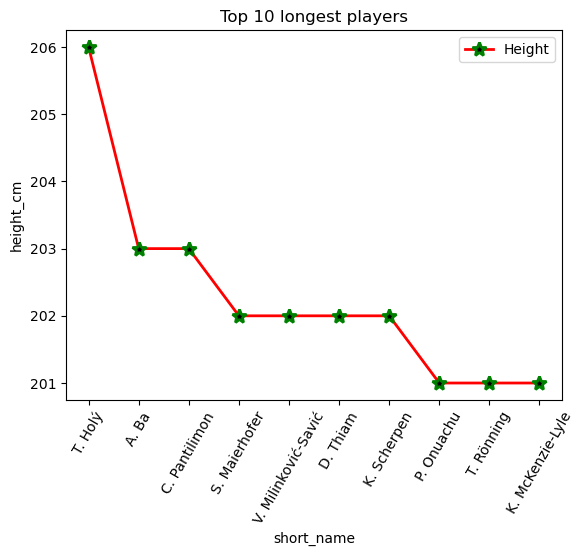

In [36]:
sns.lineplot(x='short_name', y='height_cm', data=top_10_longest_players, color='red', label='Height', marker='*', markersize=10,
             markerfacecolor='black', markeredgewidth=2, markeredgecolor="green", linewidth=2)
plt.title('Top 10 longest players')
plt.xticks(rotation=60)
plt.show()

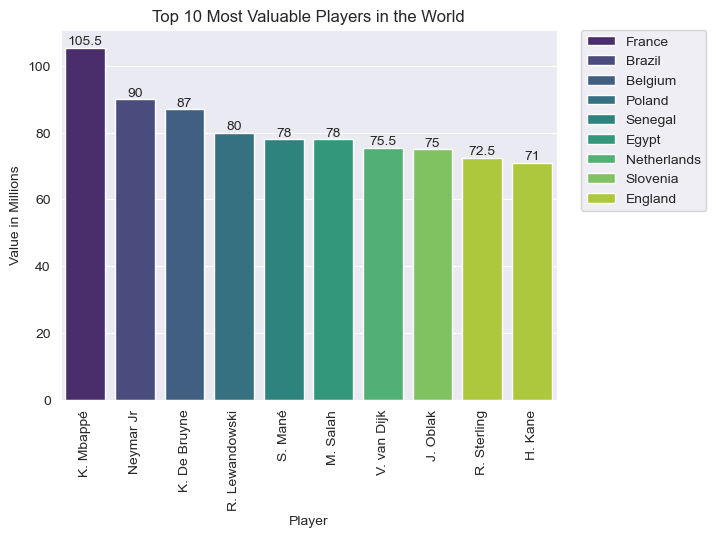

In [37]:
# top 10 most valuable players in the world
vl= df.sort_values(by='value_eur_m', ascending=False).head(10)
sns.set_style('darkgrid')
ax = sns.barplot(x='short_name', y='value_eur_m', data=vl, palette='viridis', hue='nationality', dodge=False, ci=None)
for bars in ax.containers:
    ax.bar_label(bars)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xticks(rotation=90)
plt.xlabel('Player')
plt.ylabel('Value in Millions')
plt.title('Top 10 Most Valuable Players in the World')
plt.show()

## Radar Chart

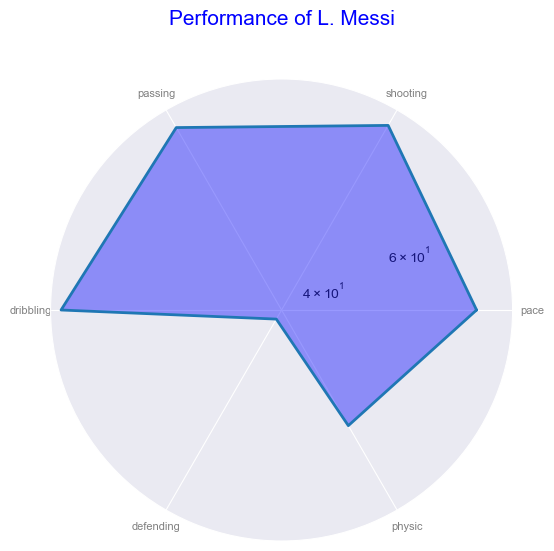

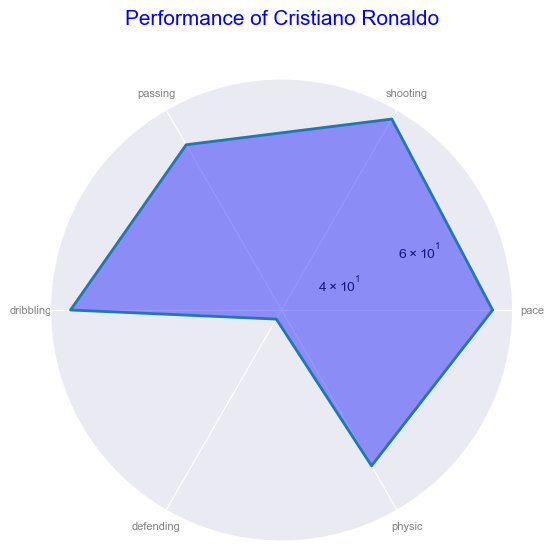

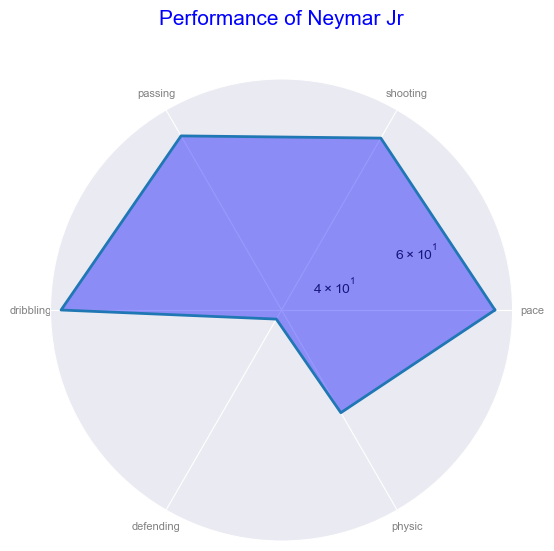

In [48]:
from math import pi

# Load the actual dataset
file_path = 'players_21.csv'  
df = pd.read_csv(file_path)

# Function to create radar chart
def create_radar_chart(data, player_name, attributes, title):
    player_data = data[data['short_name'] == player_name]
    
    if player_data.empty:
        print(f"No data found for player: {player_name}")
        return
    
    num_vars = len(attributes)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the loop

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], attributes, color='grey', size=8)
    ax.set_rscale('log')
    
    values = player_data[attributes].values.flatten().tolist()
    values += values[:1]  # Complete the loop

    ax.plot(angles, values, linewidth=2, linestyle='solid')
    ax.fill(angles, values, 'b', alpha=0.4)
    plt.title(title, size=15, color='blue', y=1.1)
    plt.show()

# Define players and attributes
players = ['L. Messi', 'Cristiano Ronaldo', 'Neymar Jr']  # Replace with players from your dataset
attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# Create radar charts for each player
for player in players:
    create_radar_chart(df, player, attributes, f'Performance of {player}')

## Evaluate Team Strategies

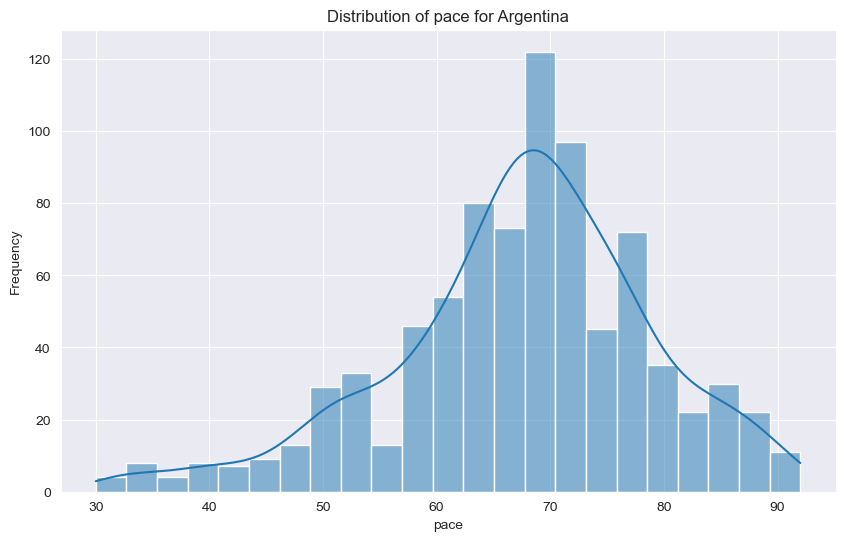

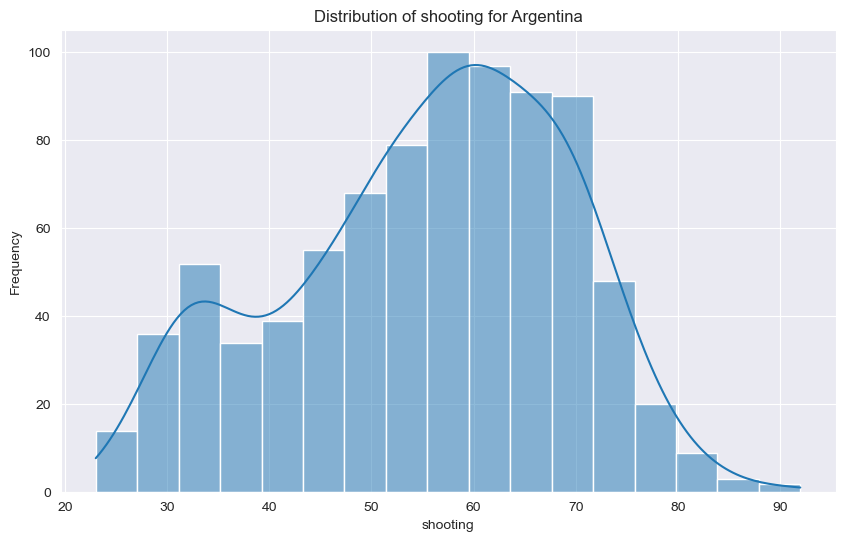

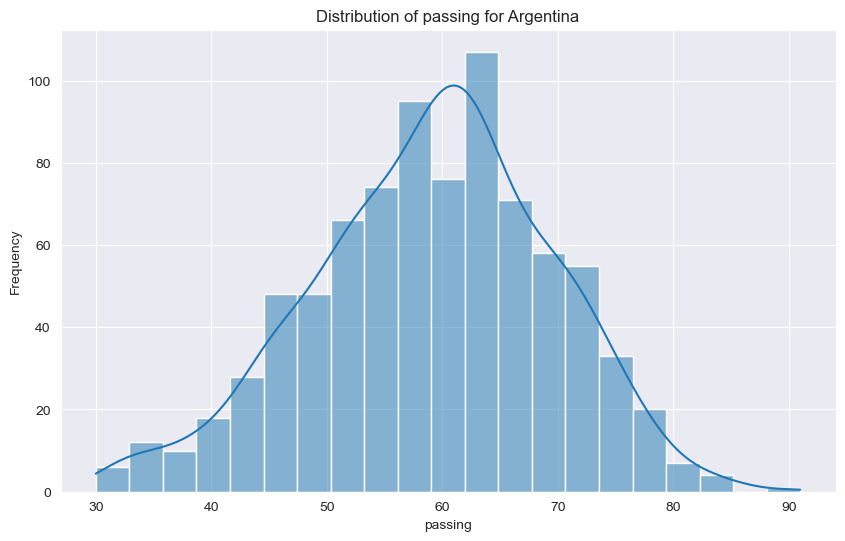

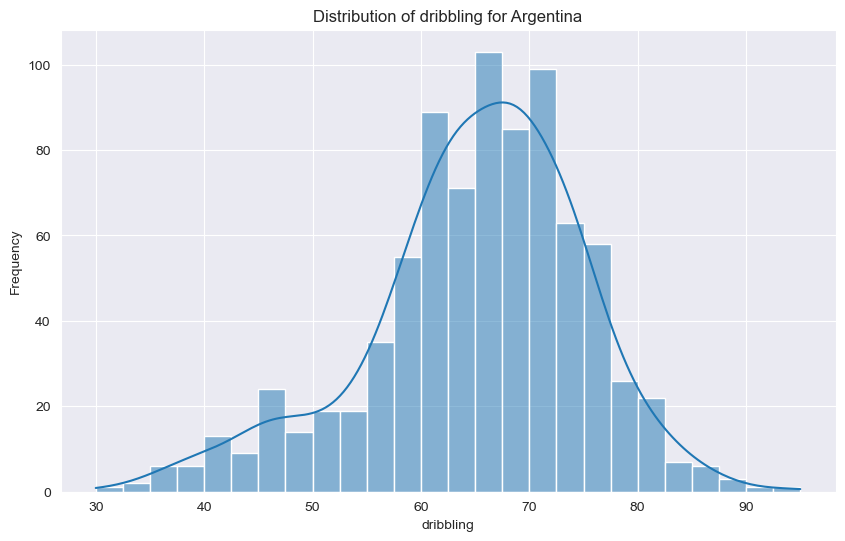

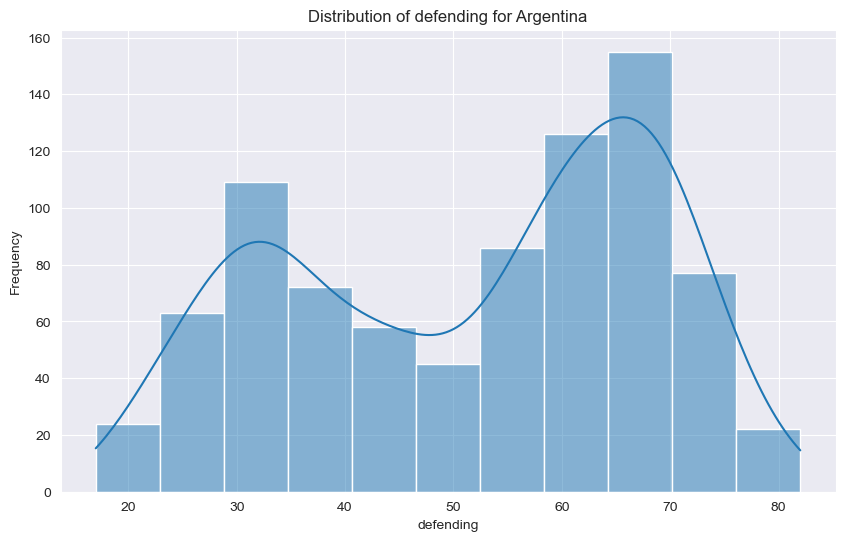

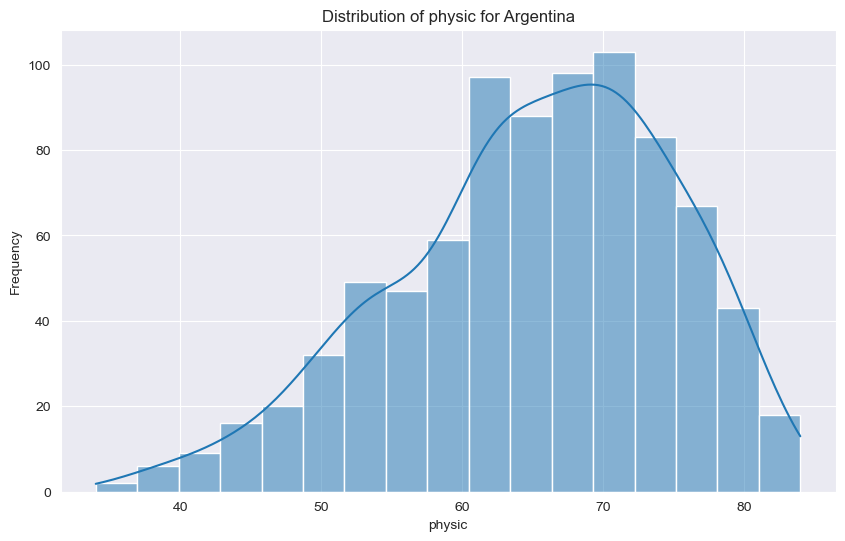

In [47]:
# Filter data for a specific team
team_name = 'Argentina'  # Replace with the actual team name
team_data = df[df['nationality'] == team_name]

# Plot distribution of key metrics
metrics = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.histplot(team_data[metric], kde=True)
    plt.title(f'Distribution of {metric} for {team_name}')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.show()

### Tactical analysis

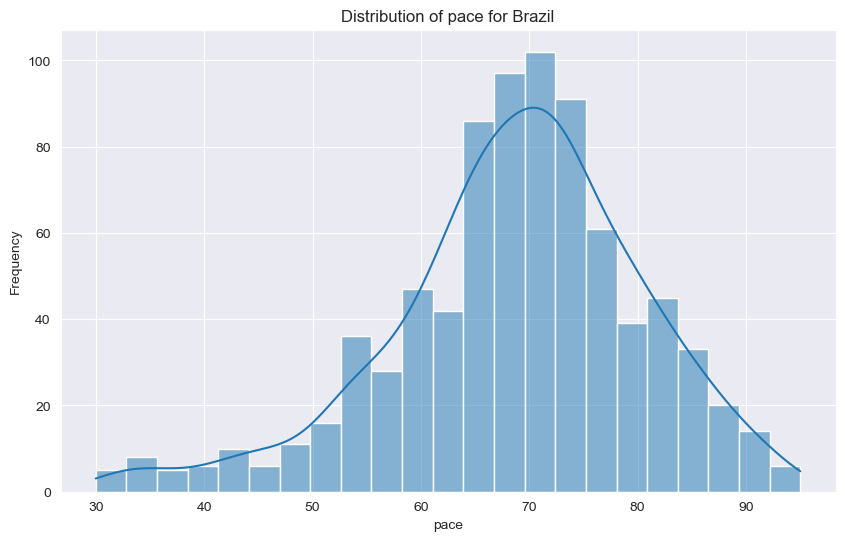

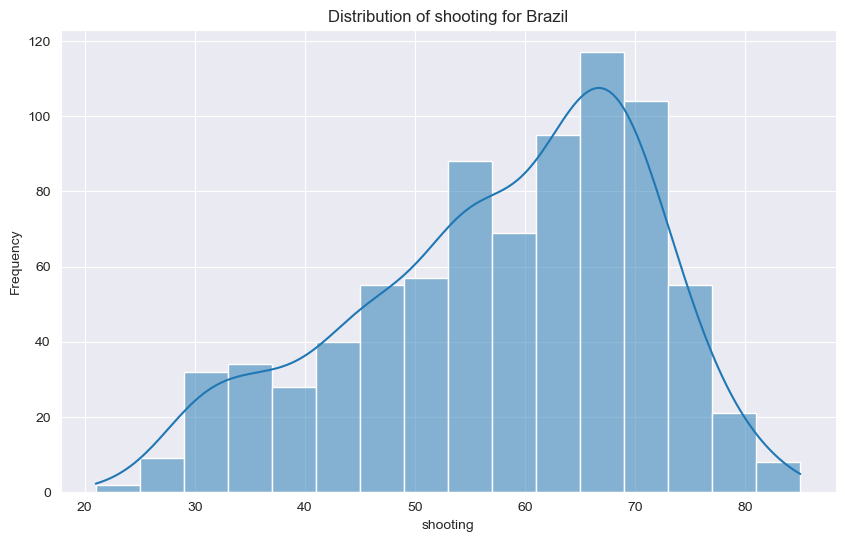

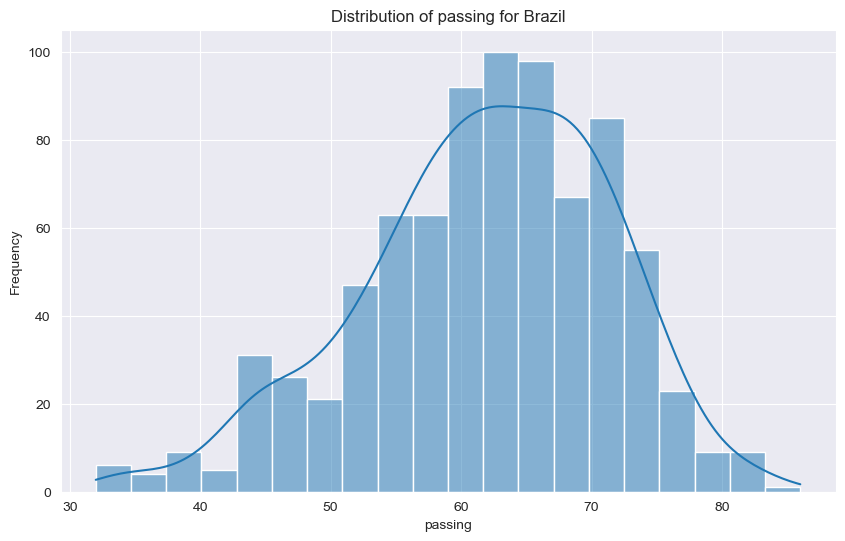

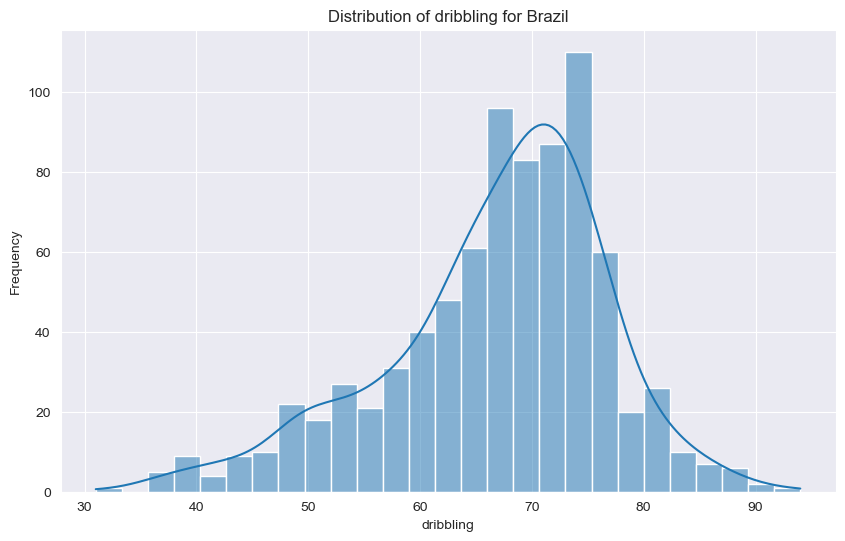

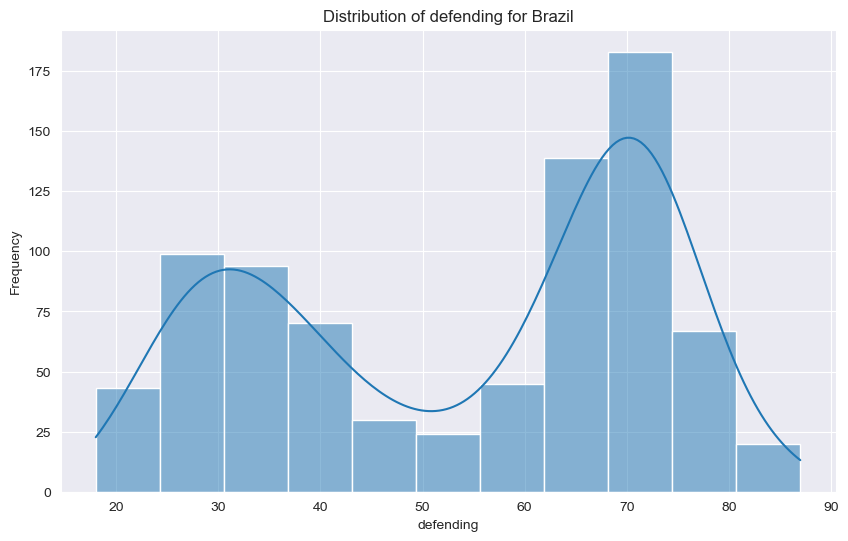

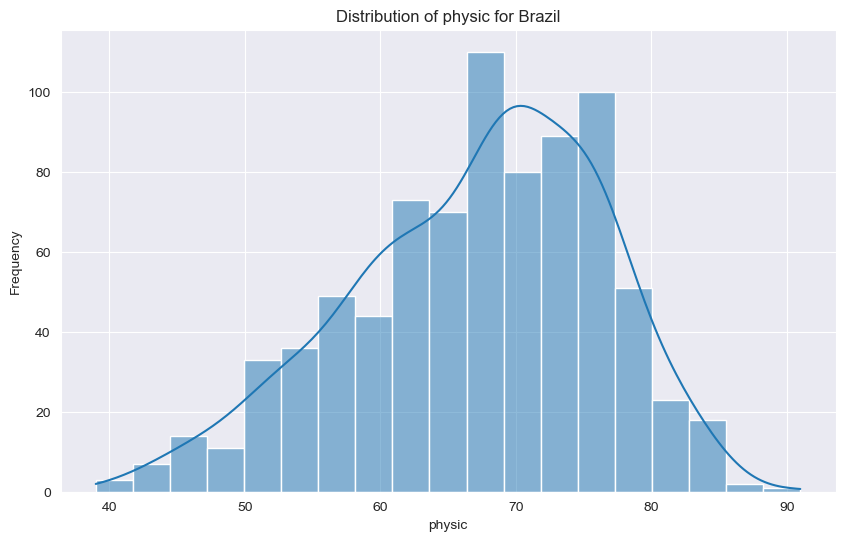

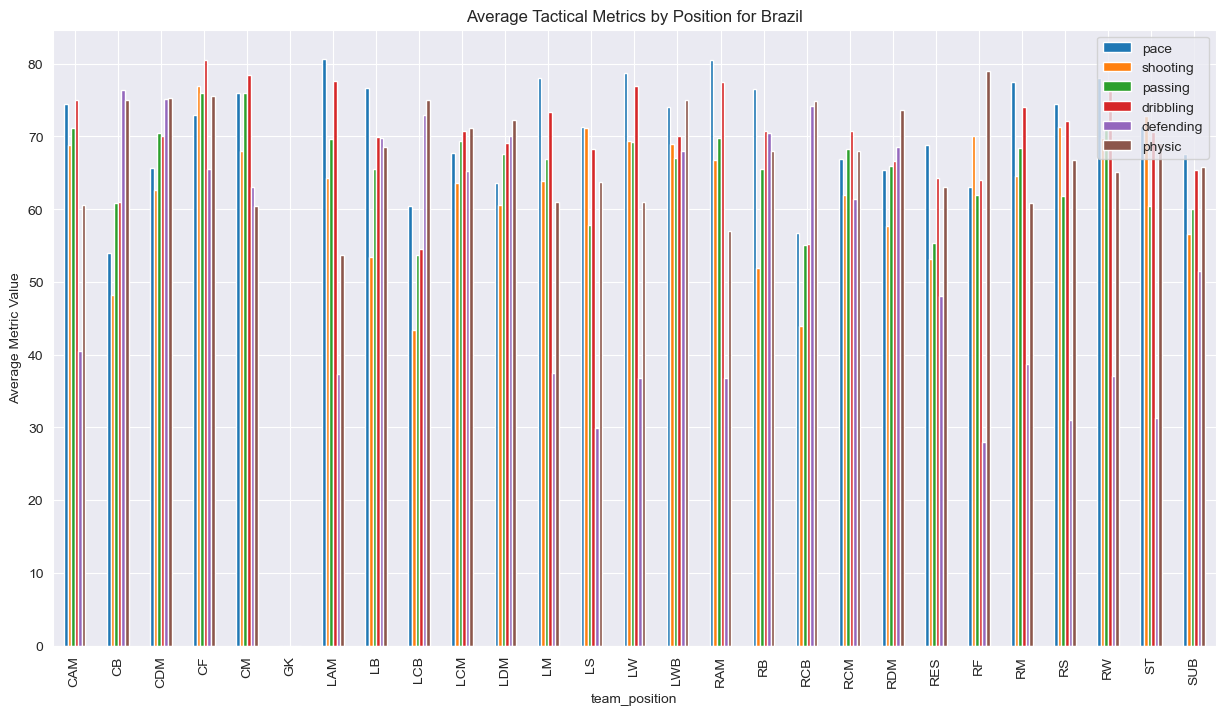

In [49]:
# Filter data for a specific team
team_name = 'Brazil'  # Replace with the actual team name
team_data = df[df['nationality'] == team_name]

# Define key metrics for tactical analysis
tactical_metrics = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# Plot distribution of key metrics
for metric in tactical_metrics:
    plt.figure(figsize=(10, 6))
    sns.histplot(team_data[metric], kde=True)
    plt.title(f'Distribution of {metric} for {team_name}')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.show()

# Group by team position and calculate average metrics
position_metrics = team_data.groupby('team_position')[tactical_metrics].mean().reset_index()

# Visualize average metrics by position
position_metrics.set_index('team_position').plot(kind='bar', figsize=(15, 8))
plt.title(f'Average Tactical Metrics by Position for {team_name}')
plt.ylabel('Average Metric Value')
plt.show()


### Set-Piece Optimization

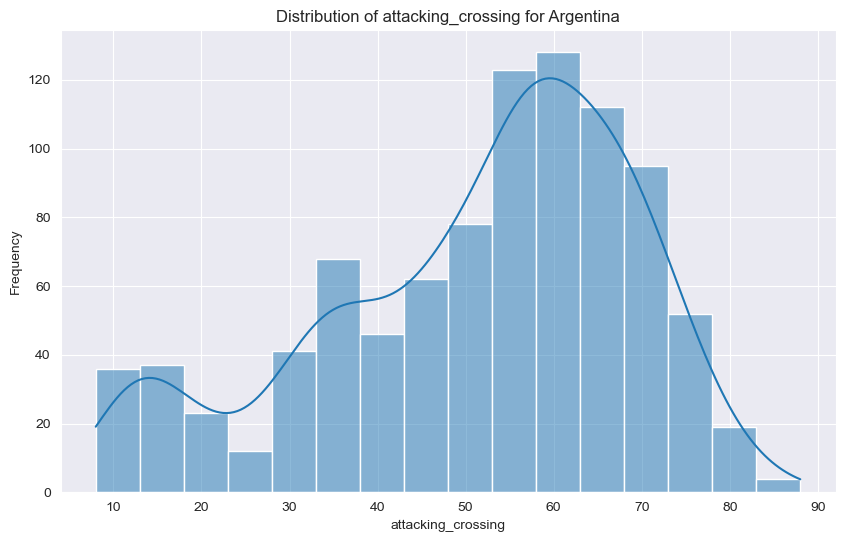

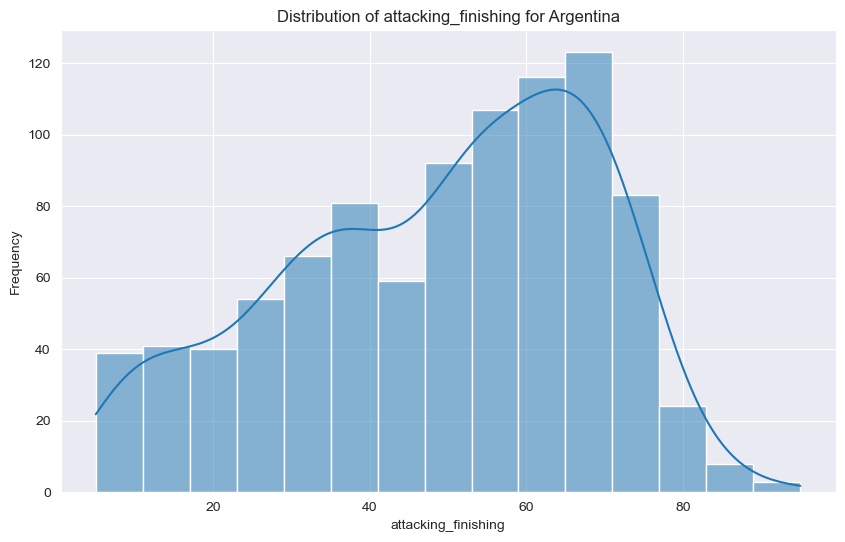

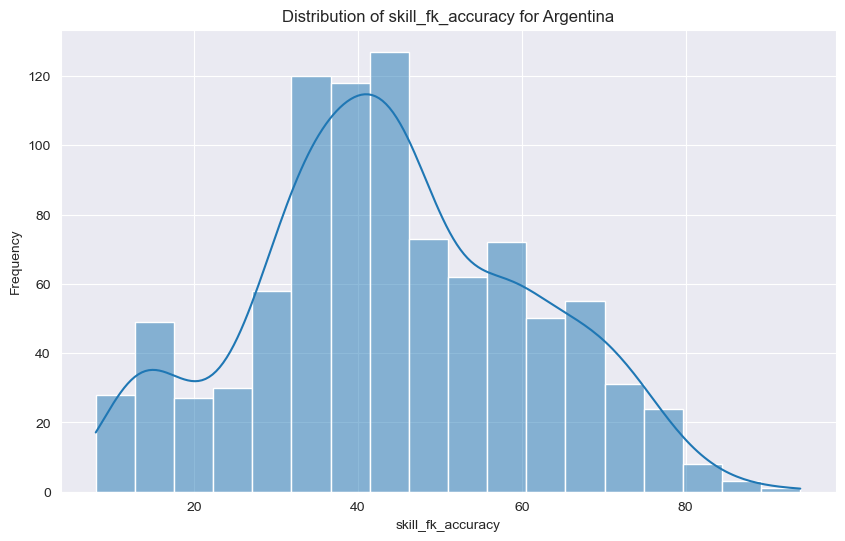

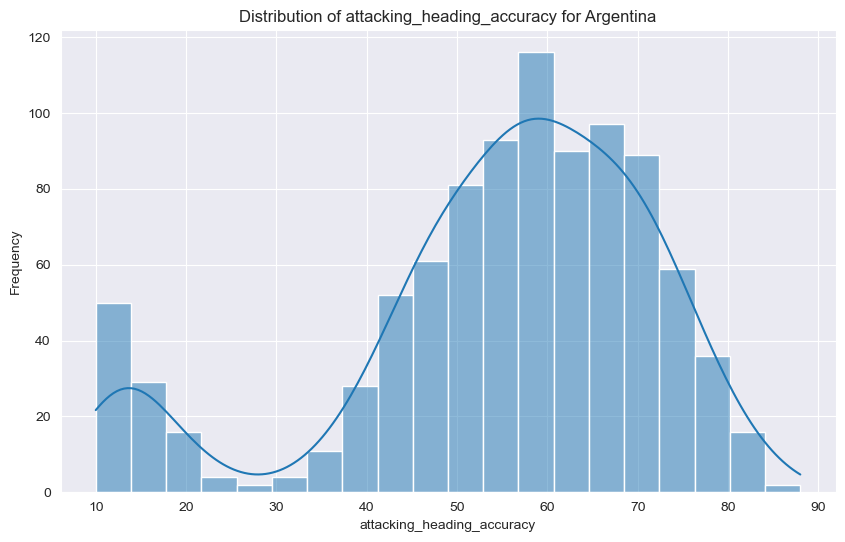

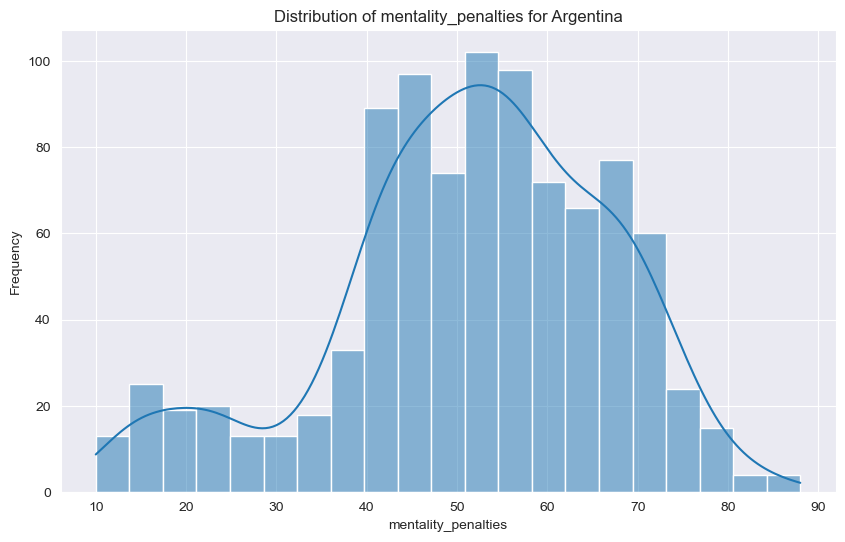

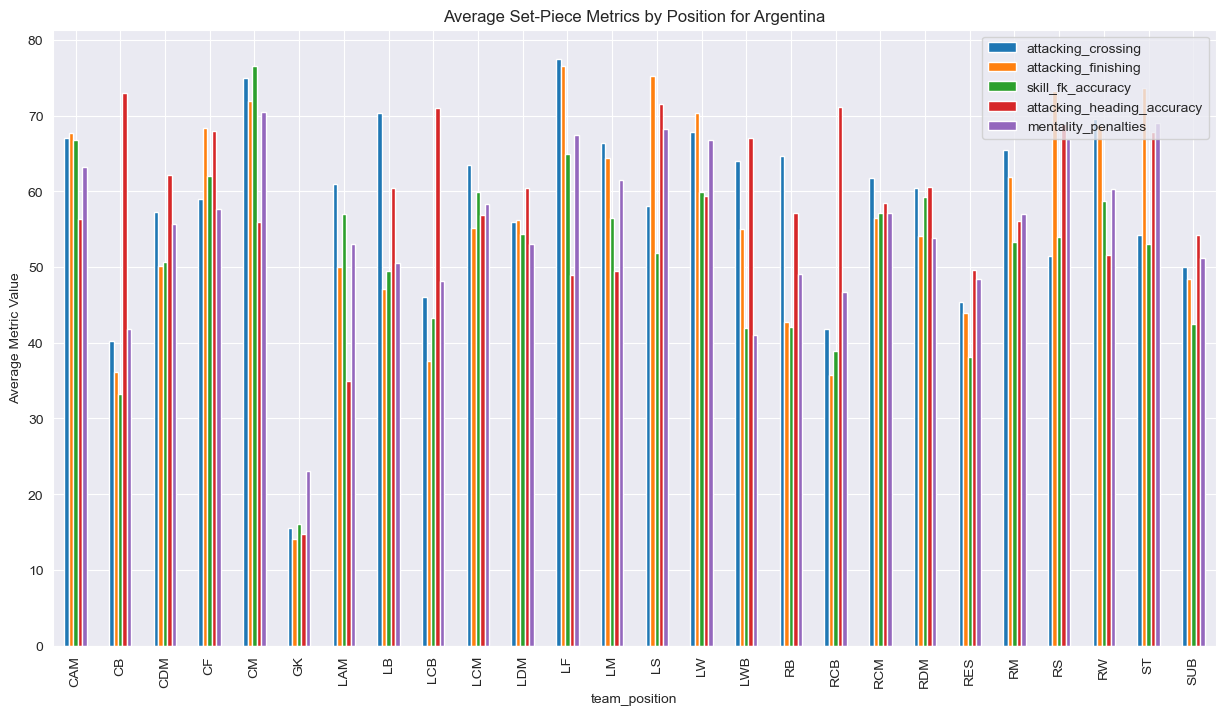

In [44]:
# Define key metrics for set-piece analysis
set_piece_metrics = ['attacking_crossing', 'attacking_finishing', 'skill_fk_accuracy', 'attacking_heading_accuracy', 'mentality_penalties']

# Plot distribution of key metrics for set-pieces
for metric in set_piece_metrics:
    plt.figure(figsize=(10, 6))
    sns.histplot(team_data[metric], kde=True)
    plt.title(f'Distribution of {metric} for {team_name}')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.show()

# Group by team position and calculate average metrics for set-pieces
set_piece_position_metrics = team_data.groupby('team_position')[set_piece_metrics].mean().reset_index()

# Visualize average set-piece metrics by position
set_piece_position_metrics.set_index('team_position').plot(kind='bar', figsize=(15, 8))
plt.title(f'Average Set-Piece Metrics by Position for {team_name}')
plt.ylabel('Average Metric Value')
plt.show()


### Opponent Profiling

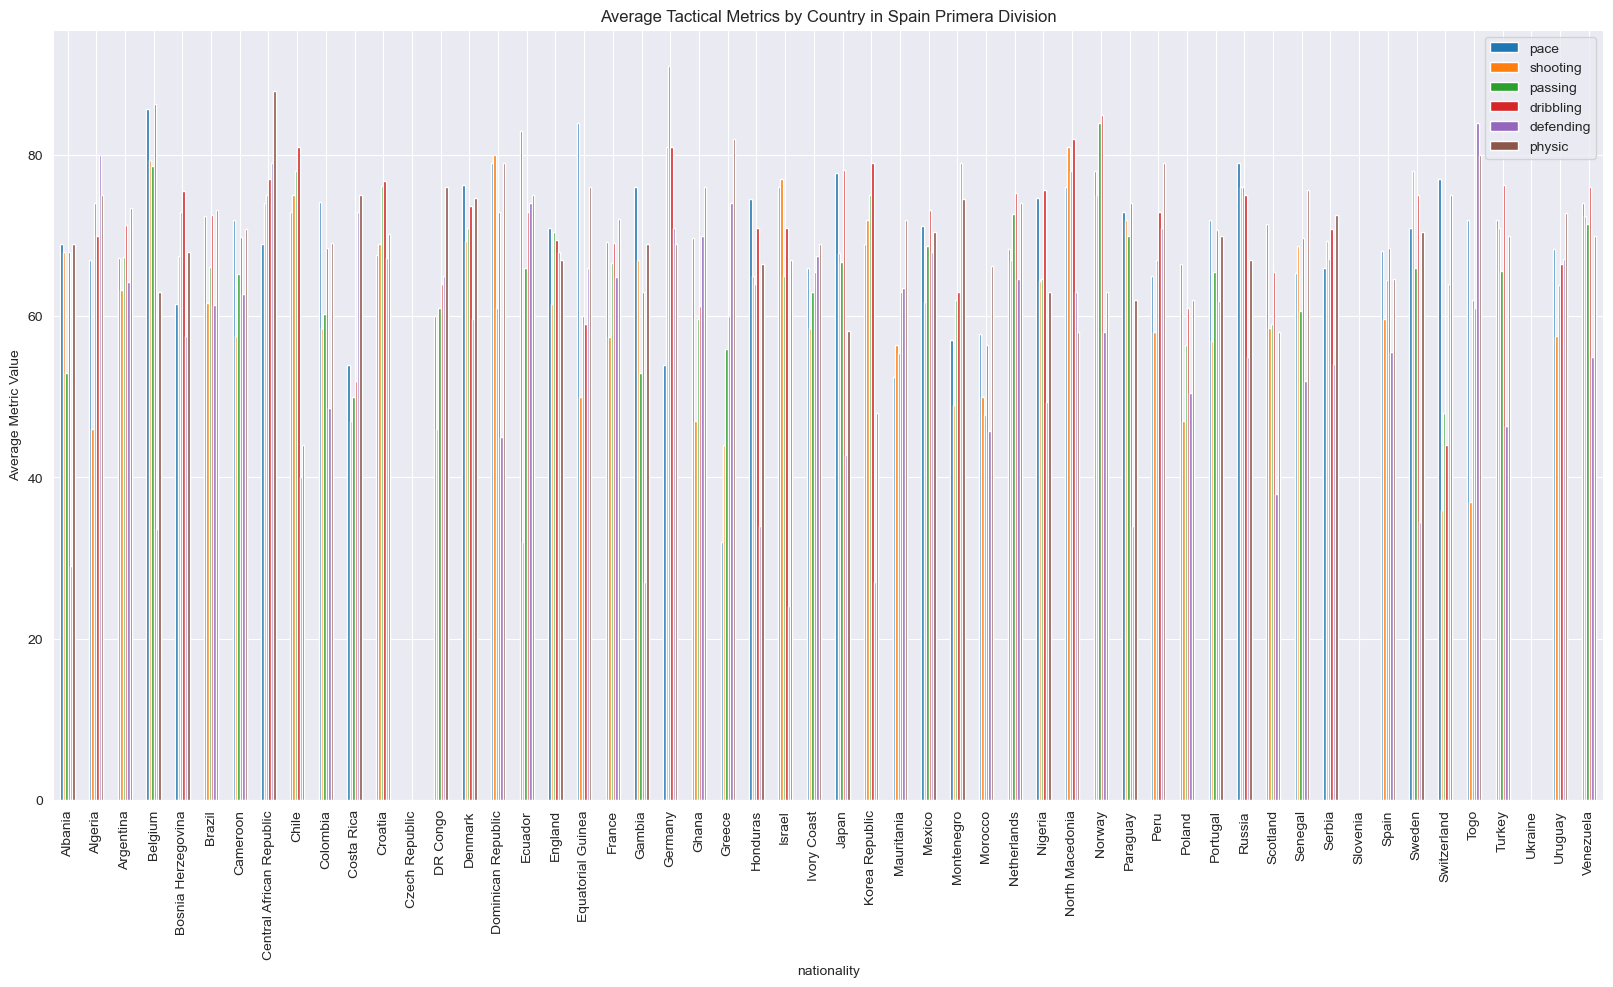

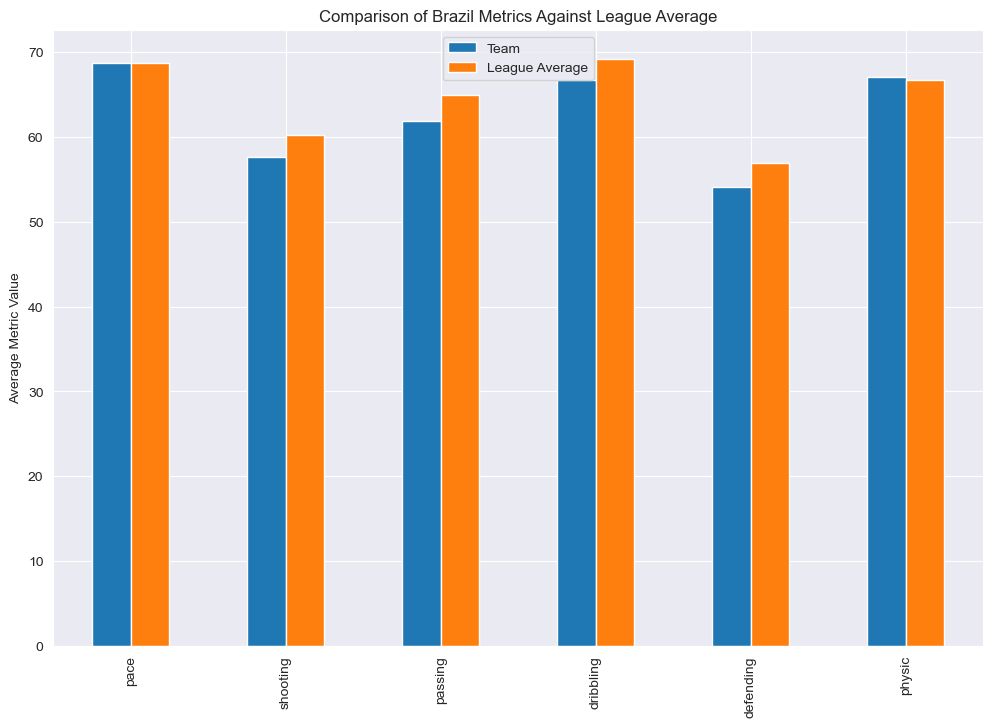

In [50]:
# Filter data for all teams in the league
league_name = 'Spain Primera Division'  # Replace with the actual league name
league_data = df[df['league_name'] == league_name]

# Calculate average metrics for the league
league_metrics = league_data.groupby('nationality')[tactical_metrics].mean().reset_index()

# Visualize average metrics for all teams in the league
league_metrics.set_index('nationality').plot(kind='bar', figsize=(20, 10))
plt.title(f'Average Tactical Metrics by Country in {league_name}')
plt.ylabel('Average Metric Value')
plt.show()

# Compare team's metrics against league average
team_avg_metrics = team_data[tactical_metrics].mean()
league_avg_metrics = league_data[tactical_metrics].mean()

comparison = pd.DataFrame({'Team': team_avg_metrics, 'League Average': league_avg_metrics})
comparison.plot(kind='bar', figsize=(12, 8))
plt.title(f'Comparison of {team_name} Metrics Against League Average')
plt.ylabel('Average Metric Value')
plt.show()


## Model Development

In [51]:
# Load and preprocess data
file_path = 'dataset.csv'  
df1 = pd.read_csv(file_path)

In [52]:
# Basic Data Cleaning and Feature Engineering
df1 = df1.dropna()  # Handle missing values


In [53]:
# Ensure 'dob' column is parsed correctly
df1['age'] = 2024 - pd.to_datetime(df1['dob']).dt.year
df1['bmi'] = df1['weight_kg'] / (df1['height_cm'] / 100) ** 2


In [54]:
# Define the target variable
df1['high_risk'] = (df1['total_days_injured'] > df1['total_days_injured'].median()).astype(int)


In [55]:
# Define features and target
features = ['age', 'height_cm', 'weight_kg', 'season_minutes_played', 'season_games_played',
             'season_matches_in_squad', 'total_minutes_played', 'total_games_played', 'bmi',
             'pace', 'physic', 'fifa_rating', 'work_rate_numeric', 'position_numeric',
             'significant_injury_prev_season', 'cumulative_days_injured']
target = 'high_risk'


In [56]:
# Ensure all feature columns exist in the dataset
missing_features = [feature for feature in features if feature not in df1.columns]
if missing_features:
    raise ValueError(f"Missing columns in dataset: {missing_features}")


In [57]:
X = df1[features]
y = df1[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [58]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [59]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}


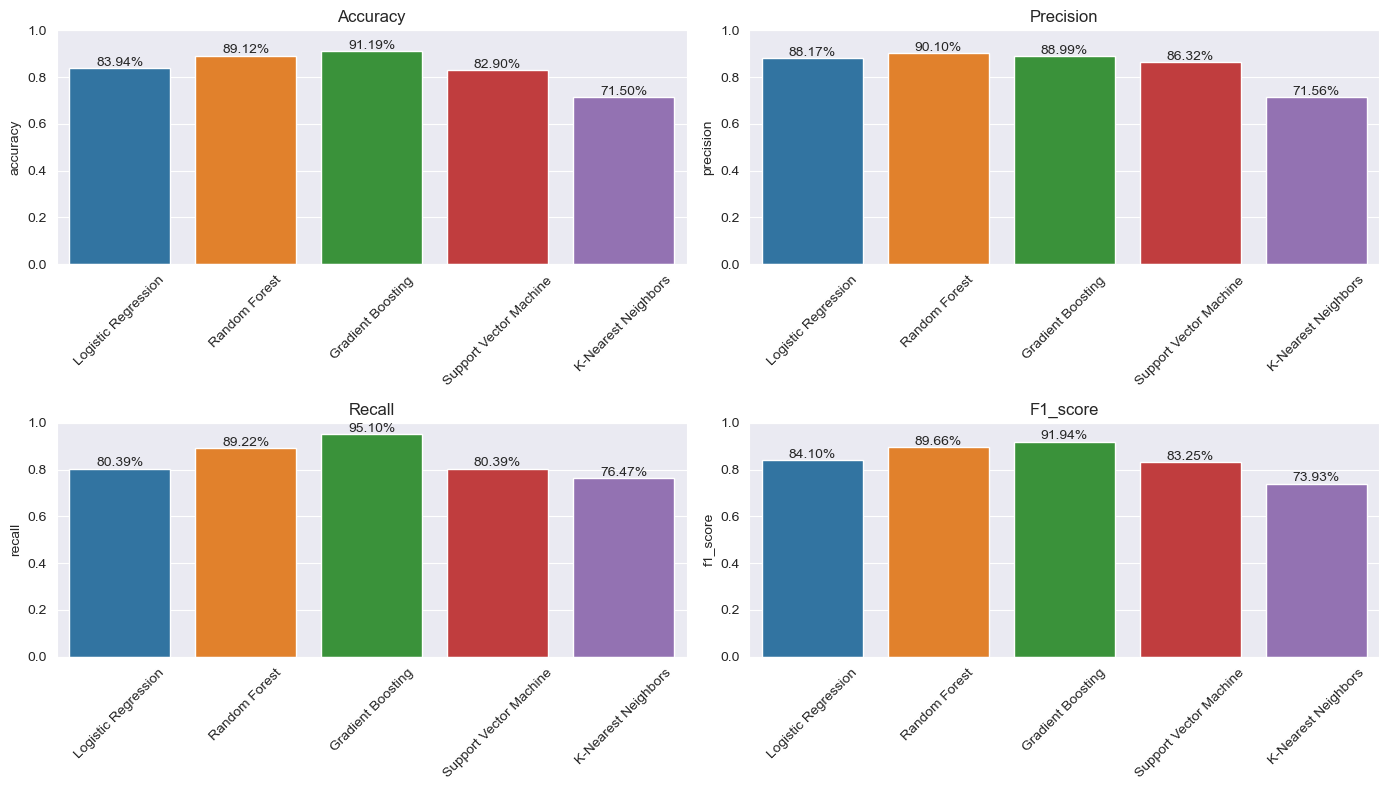

In [60]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# Plotting the results with percentage annotations
plt.figure(figsize=(14, 8))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x=results_df.index, y=results_df[metric])
    plt.title(metric.capitalize())
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    for index, value in enumerate(results_df[metric]):
        plt.text(index, value + 0.01, f"{value:.2%}", ha='center')

plt.tight_layout()
plt.show()

In [61]:
# Gradient Boosting has the highest accuracy
best_model = models['Gradient Boosting']

# Save the model
model_filename = 'gradient_boosting_model.pkl'
joblib.dump(best_model, model_filename)

# Save the scaler
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)

print(f"Model saved as {model_filename}")
print(f"Scaler saved as {scaler_filename}")

Model saved as gradient_boosting_model.pkl
Scaler saved as scaler.pkl


## Real-Time Decision Support

In [63]:
# Load the model and scaler
model = joblib.load('gradient_boosting_model.pkl')
scaler = joblib.load('scaler.pkl')

# Function to preprocess new data
def preprocess_data(input_data):
    input_data_scaled = scaler.transform(input_data)
    return input_data_scaled

# Function to predict injury risk
def predict_injury_risk(input_data):
    input_data_scaled = preprocess_data(input_data)
    predictions = model.predict(input_data_scaled)
    return predictions

# Function to generate random data for predictions
def generate_random_data():
    data = []
    for i in range(10):
        # Randomly generate data for each feature
        age = np.random.randint(18, 40)
        height_cm = np.random.randint(150, 200)
        weight_kg = np.random.randint(60, 100)
        season_minutes_played = np.random.randint(0, 2000)
        season_games_played = np.random.randint(0, 20)
        season_matches_in_squad = np.random.randint(0, 20)
        total_minutes_played = np.random.randint(0, 10000)
        total_games_played = np.random.randint(0, 200)
        bmi = weight_kg / ((height_cm / 100) ** 2)
        pace = np.random.randint(0, 100)
        physic = np.random.randint(0, 100)
        fifa_rating = np.random.randint(0, 100)
        work_rate_numeric = np.random.randint(0, 5)
        position_numeric = np.random.randint(0, 10)
        significant_injury_prev_season = np.random.randint(0, 2)
        cumulative_days_injured = np.random.randint(0, 400)

        # Append the generated data to the list
        data.append({
            'age': age,
            'height_cm': height_cm,
            'weight_kg': weight_kg,
            'season_minutes_played': season_minutes_played,
            'season_games_played': season_games_played,
            'season_matches_in_squad': season_matches_in_squad,
            'total_minutes_played': total_minutes_played,
            'total_games_played': total_games_played,
            'bmi': bmi,
            'pace': pace,
            'physic': physic,
            'fifa_rating': fifa_rating,
            'work_rate_numeric': work_rate_numeric,
            'position_numeric': position_numeric,
            'significant_injury_prev_season': significant_injury_prev_season,
            'cumulative_days_injured': cumulative_days_injured
        })
    
    return pd.DataFrame(data)

# Generate random data
new_data = generate_random_data()

# Predict injury risk
risk_predictions = predict_injury_risk(new_data)
print("Injury Risk Predictions:", risk_predictions)

# Display the new data with predictions
new_data['injury_risk_prediction'] = risk_predictions
print(new_data)


Injury Risk Predictions: [0 0 1 1 1 0 0 0 0 0]
   age  height_cm  weight_kg  season_minutes_played  season_games_played  \
0   37        161         92                    401                    6   
1   33        160         65                   1128                    1   
2   19        189         82                    720                   11   
3   20        184         82                   1656                    6   
4   38        172         70                   1388                   15   
5   30        164         79                    831                    6   
6   34        191         66                     27                   18   
7   18        161         60                    517                    3   
8   24        191         78                    959                    7   
9   20        174         87                   1717                   12   

   season_matches_in_squad  total_minutes_played  total_games_played  \
0                       18                  

## Testing and Validation

In [69]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
results[name] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}
# Display results
results_df = pd.DataFrame(results).T
print(results_df)

                        accuracy  precision    recall  f1_score
Logistic Regression     0.839378   0.881720  0.803922  0.841026
Random Forest           0.891192   0.900990  0.892157  0.896552
Gradient Boosting       0.911917   0.889908  0.950980  0.919431
Support Vector Machine  0.829016   0.863158  0.803922  0.832487
K-Nearest Neighbors     0.911917   0.889908  0.950980  0.919431
